# Part 2 — Colab version (When Can We Trust Neural Network Confidence?)

**Cách chạy:** `Runtime → Run all`. Không cần GPU (phân tích chỉ là numpy trên ma trận 10000×10; CPU mất khoảng 30 giây).

**Logits lấy từ đâu** (chỉnh `SOURCE` ở cell "Step 1"):
| `SOURCE` | Cách làm | Khi nào dùng |
|---|---|---|
| `"upload"` (mặc định) | Upload `part1_results.zip` **hoặc** `clean_logits.npz` của Part 1 khi được hỏi | Khuyến nghị: dùng **đúng** logits Part 1 đã báo cáo (I1) |
| `"drive"` | Đọc file đó từ Google Drive (`DRIVE_PATH`) | File đã nằm trên Drive chung của nhóm |
| `"recompute"` | Tải checkpoint huyvnphan ResNet-18 (~979 MB zip) và chạy inference lại | Không có file Part 1. Trên GPU kết quả có thể lệch Part 1 ở mức rất nhỏ. Mục kiểm tra trên 10 kiến trúc (Cell 10) sẽ bị bỏ qua vì chỉ có logits ResNet-18 |

Nếu file đã có sẵn trong `/content` (kéo thả vào thanh Files bên trái), notebook tự dùng luôn, không hỏi upload.

Cuối notebook: toàn bộ hình + bảng được nén thành `part2_results.zip` và tải về.

In [1]:
import os
BASE = "/content" if os.path.isdir("/content") else os.getcwd()     # works on Colab and locally
WORK = os.path.join(BASE, "part2"); os.makedirs(WORK, exist_ok=True); os.chdir(WORK)
print("working directory:", os.getcwd())

working directory: /content/part2


## Step 0 — Module metric dùng chung (`calib_metrics.py`, giống hệt bản local) + unit test

In [2]:
%%writefile calib_metrics.py
"""Shared calibration / selective-prediction metrics (Part 2, reused by Part 3 and Part 4).

ECE, ACE and reliability bins are copied verbatim from DeepLearning_Part1.ipynb (Cell 3) so that
all Parts report identical numbers:
  - ECE: 15 equal-width bins (lo, hi]  (Guo et al., 2017)
  - ACE: top-label, 15 equal-mass bins
Confidence = max softmax probability. Every probability is computed in float64.
"""
import numpy as np
from scipy.stats import spearmanr, kendalltau

N_BINS = 15


# ----------------------------------------------------------------------------- probabilities
def softmax_T(logits, T=1.0):
    """softmax(z / T), numerically stable, float64.
    The max is subtracted in the logits' own dtype before casting, exactly like Part 1's softmax_np,
    so at T = 1 the probabilities are bit-identical to Part 1 (same ECE bins and same ACE sort order)."""
    z = np.asarray(logits)
    z = (z - z.max(1, keepdims=True)).astype(np.float64) / T
    e = np.exp(z)
    return e / e.sum(1, keepdims=True)


def log_confidence(logits, T=1.0):
    """log(max softmax(z / T)) = -log sum_j exp((z_j - z_max) / T). Same ordering as confidence,
    but never saturates at 1.0, so it is the score used for ranking."""
    z = np.asarray(logits)
    z = (z - z.max(1, keepdims=True)).astype(np.float64) / T    # same arithmetic order as softmax_T
    e = np.exp(z)
    e[np.arange(len(e)), z.argmax(1)] = 0.0          # drop the max term (== 1) and use log1p on the rest,
    return -np.log1p(e.sum(1))                       # so tiny tails are not lost to 1 + eps == 1


def predict(logits, labels, T=1.0):
    """Per-sample record: prediction, confidence, ranking score and correctness (0/1 float)."""
    p = softmax_T(logits, T)
    pred = p.argmax(1)
    return dict(pred=pred, conf=p.max(1), score=log_confidence(logits, T),
                correct=(pred == np.asarray(labels)).astype(float))


# ----------------------------------------------------------------------------- calibration (identical to Part 1)
def ece_score(conf, correct, n_bins=N_BINS):
    idx = np.digitize(conf, np.linspace(0, 1, n_bins + 1)[1:-1], right=True)      # bins (lo, hi]
    sc = np.bincount(idx, weights=conf, minlength=n_bins)
    sa = np.bincount(idx, weights=correct, minlength=n_bins)
    return np.abs(sa - sc).sum() / len(conf)          # == sum_b (n_b/N)|acc_b - conf_b|


def ace_score(conf, correct, n_bins=N_BINS):
    o = np.argsort(conf, kind="stable"); c = conf[o]; a = correct[o].astype(float)
    return float(np.mean([abs(a[p].mean() - c[p].mean()) for p in np.array_split(np.arange(len(c)), n_bins)]))


def reliability_bins(conf, correct, n_bins=N_BINS):
    """Per equal-width bin: mean confidence, accuracy, count (NaN for empty bins)."""
    idx = np.digitize(conf, np.linspace(0, 1, n_bins + 1)[1:-1], right=True)
    cnt = np.bincount(idx, minlength=n_bins).astype(float)
    with np.errstate(invalid="ignore", divide="ignore"):
        bc = np.bincount(idx, weights=conf, minlength=n_bins) / cnt
        ba = np.bincount(idx, weights=correct, minlength=n_bins) / cnt
    return bc, ba, cnt


def signed_gap(conf, correct):
    """mean confidence - accuracy.  > 0: overconfident, < 0: underconfident."""
    return float(conf.mean() - correct.mean())


def binwise_gap(conf, correct, n_bins=N_BINS):
    """Signed gap (conf - acc) per equal-width bin, with counts. Shows whether the direction is
    the same in every bin, which the global signed gap alone cannot show."""
    bc, ba, cnt = reliability_bins(conf, correct, n_bins)
    return bc - ba, cnt


# ----------------------------------------------------------------------------- selective prediction
def _order(score):
    return np.argsort(-np.asarray(score), kind="stable")          # most confident first


def risk_coverage(score, correct):
    """Accept the k most confident predictions, k = 1..N. Returns (coverage, risk)."""
    err = 1.0 - np.asarray(correct, dtype=float)[_order(score)]
    k = np.arange(1, len(err) + 1)
    return k / len(err), np.cumsum(err) / k


def risk_at(score, correct, coverage):
    """Error rate on the round(coverage * N) most confident predictions."""
    k = int(round(coverage * len(score)))
    return float(1.0 - np.asarray(correct, dtype=float)[_order(score)[:k]].mean())


def oracle_score(correct):
    """Perfect ranking: every correct prediction ranked above every error (lower bound of risk)."""
    return np.asarray(correct, dtype=float)


def aurc(score, correct):
    """Area under the risk-coverage curve (secondary number only; never read alone)."""
    return float(risk_coverage(score, correct)[1].mean())


def e_aurc(score, correct):
    """AURC minus the oracle AURC at the same accuracy: isolates ranking quality from accuracy."""
    return aurc(score, correct) - aurc(oracle_score(correct), correct)


# ----------------------------------------------------------------------------- ranking agreement
def topk_overlap(score_a, score_b, frac):
    """|top-frac set under a  ∩  top-frac set under b| / size of the set."""
    k = int(round(frac * len(score_a)))
    return len(np.intersect1d(_order(score_a)[:k], _order(score_b)[:k])) / k


def ranking_agreement(score_ref, score, fracs=(0.8, 0.6)):
    out = dict(spearman=float(spearmanr(score_ref, score).statistic),
               kendall=float(kendalltau(score_ref, score).statistic))
    for f in fracs:
        out[f"overlap_top{int(round(100 * f))}"] = topk_overlap(score_ref, score, f)
    return out


# ----------------------------------------------------------------------------- bootstrap
DEFAULT_METRICS = {
    "acc":    lambda r: r["correct"].mean(),
    "conf":   lambda r: r["conf"].mean(),
    "gap":    lambda r: signed_gap(r["conf"], r["correct"]),
    "ece":    lambda r: ece_score(r["conf"], r["correct"]),
    "ace":    lambda r: ace_score(r["conf"], r["correct"]),
    "risk80": lambda r: risk_at(r["score"], r["correct"], 0.8),
    "risk60": lambda r: risk_at(r["score"], r["correct"], 0.6),
}


def paired_bootstrap(records, metrics=None, B=1000, seed=0):
    """Resample the test set B times; the SAME indices are used for every record in each draw,
    so differences between records (e.g. T=0.5 minus T=1) get valid paired CIs.
    Returns {record_name: {metric: array(B)}}."""
    metrics = metrics or DEFAULT_METRICS
    rng = np.random.default_rng(seed)
    N = len(next(iter(records.values()))["correct"])
    out = {n: {m: np.empty(B) for m in metrics} for n in records}
    for b in range(B):
        idx = rng.integers(0, N, N)
        for n, r in records.items():
            sub = {k: v[idx] for k, v in r.items()}
            for m, fn in metrics.items():
                out[n][m][b] = fn(sub)
    return out


def ci(samples, level=95):
    lo, hi = np.percentile(samples, [(100 - level) / 2, 100 - (100 - level) / 2])
    return float(lo), float(hi)


# ----------------------------------------------------------------------------- team figure style (I5, see STYLE.md)
# Palette and typography taken from the team report (tailieuchinh/main.pdf): bold figure titles, white
# background, light grid, and the six series colours sampled from its figures.
PAL = {"green": "#1b7837", "blue": "#2166ac", "dark": "#333333", "orange": "#d6600a", "red": "#c0392b",
       "purple": "#6a3d9a", "gray": "#8c8c8c"}
RC_PARAMS = {"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25, "font.size": 10,
             "font.family": "DejaVu Sans", "savefig.dpi": 150, "savefig.bbox": "tight",
             "figure.titlesize": 13, "figure.titleweight": "bold", "axes.titlesize": 11,
             "axes.edgecolor": "black", "legend.fontsize": 8, "legend.framealpha": .9,
             "errorbar.capsize": 4,
             "axes.prop_cycle": __import__("cycler").cycler(color=[PAL[k] for k in ("blue", "orange", "green", "red", "purple", "dark")])}
C = {  # semantic colours shared by every Part (reliability colours as rendered in main.pdf)
    "acc": "#1f77b4", "over": "#f1b3b4", "over_edge": "#c0392b", "under": "#238584", "under_edge": "#1b5e5d",
    "over_area": PAL["red"], "under_area": PAL["blue"],          # filled gap areas in the line-style reliability plot
    "diag": "black", "oracle": PAL["green"], "random": PAL["gray"],
    "correct": "#1f77b4", "wrong": "#d62728"}                     # confidence histograms, as in main.pdf
FAMILY_COLOR = {"LeNet": PAL["dark"], "VGG": PAL["orange"], "ResNet": PAL["blue"], "DenseNet": PAL["green"]}   # Part 1
T_COLOR = {0.5: PAL["red"], 1.0: PAL["dark"], 2.0: PAL["blue"]}                                                # Part 2
T_MARKER = {0.5: ">", 1.0: "o", 2.0: "<"}       # Part 2: shape as a second encoding, so T is never told by colour alone
METHOD_COLOR = {"Uncalibrated": PAL["dark"], "Temperature Scaling": PAL["orange"], "Dirichlet": PAL["green"]}  # Part 4


def shades(hex_color, n, lo=.35, hi=1.0):
    """n shades of one hue, light to dark (mixed with white), for ordered series such as noise levels."""
    rgb = np.array([int(hex_color[i:i + 2], 16) for i in (1, 3, 5)]) / 255
    return [tuple(1 - a * (1 - rgb)) for a in np.linspace(lo, hi, n)]


def severity_color(s):
    """Part 3: clean (s = 0) is black, severity 1..5 go from light to dark purple."""
    import matplotlib.pyplot as plt
    return "black" if s == 0 else plt.get_cmap("Purples")(0.35 + 0.15 * (s - 1))


def apply_style():
    import matplotlib.pyplot as plt
    plt.rcParams.update(RC_PARAMS)


def fig_name(part, content, variant=None, ext="png"):
    """fig_p{part}_{content}[_{variant}].png, e.g. fig_name(3, "reliability", "gaussian_noise")."""
    return f"fig_p{part}_{content}" + (f"_{variant}" if variant else "") + f".{ext}"


def table_name(part, content, ext="csv"):
    return f"p{part}_{content}.{ext}"


# ----------------------------------------------------------------------------- plotting
def plot_reliability(ax, conf, correct, n_bins=N_BINS, title=None):
    """Bar reliability diagram in the main.pdf style: blue = accuracy, pink = overconfidence gap (bar below y = x),
    teal = underconfidence gap (bar above y = x). Colours are opaque, so the legend shows exactly what is drawn."""
    bc, ba, cnt = reliability_bins(conf, correct, n_bins)
    w = 1 / n_bins; centers = (np.arange(n_bins) + .5) * w; ok = cnt > 0
    ax.bar(centers[ok], ba[ok], width=w * .95, color=C["acc"], edgecolor="k", lw=.4, label="accuracy in bin")
    ax.bar(centers[ok], np.where(bc[ok] > ba[ok], bc[ok] - ba[ok], 0), bottom=ba[ok], width=w * .95,
           color=C["over"], edgecolor="white", lw=.4, label="over-conf gap (conf > acc)")
    ax.bar(centers[ok], np.where(ba[ok] > bc[ok], ba[ok] - bc[ok], 0), bottom=bc[ok], width=w * .95,
           color=C["under"], edgecolor="white", lw=.4, label="under-conf gap (acc > conf)")
    ax.plot(bc[ok], ba[ok], "o", color="k", ms=3, label="(mean conf, acc) of bin")
    ax.plot([0, 1], [0, 1], "--", color=C["diag"], lw=1, label="y = x")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
    if title: ax.set_title(title, fontsize=9)


def plot_reliability_curve(ax, conf, correct, color=None, marker="o", label=None, n_bins=N_BINS, min_count=10, shade=True):
    """Simpler reading of a reliability diagram: one line through (mean confidence, accuracy) of each bin, dot size
    = number of samples, and the gap to y = x filled red where the model is overconfident (below the line) and blue
    where it is underconfident (above). Bins with fewer than `min_count` samples are left out of the line (too noisy);
    plot_bin_counts shows how many samples every bin holds."""
    bc, ba, cnt = reliability_bins(conf, correct, n_bins)
    ok = cnt >= min_count
    x, y, n = bc[ok], ba[ok], cnt[ok]
    color = color or C["acc"]
    if shade:
        ax.fill_between(x, y, x, where=y <= x, interpolate=True, color=C["over_area"], alpha=.25, lw=0, label="overconfident gap (acc < conf)")
        ax.fill_between(x, y, x, where=y >= x, interpolate=True, color=C["under_area"], alpha=.25, lw=0, label="underconfident gap (acc > conf)")
    ax.plot([0, 1], [0, 1], "--", color=C["diag"], lw=1, label="perfect calibration (y = x)")
    ax.plot(x, y, "-", color=color, lw=1.8, zorder=3)
    ax.scatter(x, y, s=12 + 160 * np.sqrt(n / len(conf)), marker=marker, color=color, edgecolor="white", lw=.8, zorder=4, label=label)
    ax.set_xlim(0, 1.03); ax.set_ylim(0, 1.04)          # a little room so dots at confidence/accuracy ~1 are not clipped
    ax.set_xlabel("confidence (mean in bin)"); ax.set_ylabel("accuracy in bin")


def plot_bin_counts(ax, conf, n_bins=N_BINS):
    """Number of samples per reliability bin (log scale)."""
    _, _, cnt = reliability_bins(conf, np.zeros_like(conf), n_bins)
    w = 1 / n_bins; centers = (np.arange(n_bins) + .5) * w
    ax.bar(centers, np.maximum(cnt, 0), width=w * .95, color=PAL["gray"], edgecolor="k", lw=.4)
    ax.set_yscale("log"); ax.set_xlim(0, 1.03); ax.set_ylim(0.8, len(conf) * 15)     # headroom for the count labels
    ax.set_xlabel("confidence"); ax.set_ylabel("# samples (log)")
    for c, n in zip(centers, cnt):
        if n > 0: ax.text(c, n * 1.15, f"{int(n)}", ha="center", va="bottom", fontsize=6, rotation=90)


def plot_risk_coverage(ax, score, correct, **kw):
    cov, risk = risk_coverage(score, correct)
    ax.plot(cov, risk, **kw)
    ax.set_xlabel("coverage (fraction of predictions accepted)"); ax.set_ylabel("risk (error rate on accepted)")
    ax.set_xlim(0, 1)

Writing calib_metrics.py


In [3]:
%%writefile test_calib_metrics.py
"""Sanity tests for calib_metrics on synthetic data with known answers.  Run: python test_calib_metrics.py"""
import numpy as np
import calib_metrics as cm

rng = np.random.default_rng(0)

# 1) calibrated by construction -> ECE, ACE, gap ~ 0  (same test as Part 1)
c = rng.uniform(.5, 1, 50000); k = (rng.uniform(size=50000) < c).astype(float)
assert cm.ece_score(c, k) < 0.01 and cm.ace_score(c, k) < 0.02 and abs(cm.signed_gap(c, k)) < 0.01

# 2) overconfident by 0.15 -> ECE ~ ACE ~ gap ~ +0.15, every non-empty bin has a positive gap
k2 = (rng.uniform(size=50000) < c - .15).astype(float)
assert abs(cm.ece_score(c, k2) - .15) < .02 and abs(cm.ace_score(c, k2) - .15) < .02
assert abs(cm.signed_gap(c, k2) - .15) < .01
g, n = cm.binwise_gap(c, k2); assert (g[n > 100] > 0).all()

# 3) underconfident -> negative gap
k3 = (rng.uniform(size=50000) < np.minimum(c + .1, 1)).astype(float)
assert cm.signed_gap(c, k3) < -.05

# 4) softmax_T / log_confidence: rows sum to 1, log_confidence == log(max prob), argmax independent of T
z = rng.normal(0, 3, (2000, 10)); y = rng.integers(0, 10, 2000)
for T in (0.25, 0.5, 1, 2, 4):
    p = cm.softmax_T(z, T)
    assert np.allclose(p.sum(1), 1) and np.allclose(np.log(p.max(1)), cm.log_confidence(z, T))
    assert (p.argmax(1) == z.argmax(1)).all()
# per-sample confidence strictly decreases with T (non-tied logits)
assert (cm.softmax_T(z, .5).max(1) > cm.softmax_T(z, 1).max(1)).all()
assert (cm.softmax_T(z, 1).max(1) > cm.softmax_T(z, 2).max(1)).all()
# log_confidence keeps the order where float64 softmax saturates to exactly 1.0
big = np.zeros((2, 10)); big[:, 0] = [40, 45]                     # margins 80 and 90 at T = 0.5
assert (cm.softmax_T(big, .5).max(1) == 1.0).all()                 # both saturate -> tie
lc = cm.log_confidence(big, .5)
assert (lc < 0).all() and lc[1] > lc[0]                            # still strictly ordered

# 5) risk-coverage: full coverage risk = error rate; oracle risk = 0 until coverage = accuracy
corr = (rng.uniform(size=10000) < .9).astype(float); s = rng.normal(size=10000)
cov, risk = cm.risk_coverage(s, corr)
assert np.isclose(risk[-1], 1 - corr.mean()) and np.isclose(cov[-1], 1)
assert np.isclose(cm.risk_at(s, corr, 1.0), 1 - corr.mean())
cov_o, risk_o = cm.risk_coverage(cm.oracle_score(corr), corr)
assert (risk_o[cov_o <= corr.mean() - 1e-9] == 0).all()
assert np.isclose(cm.e_aurc(cm.oracle_score(corr), corr), 0)
# random score: risk roughly flat at the error rate
assert abs(cm.risk_at(s, corr, .5) - (1 - corr.mean())) < .02
# risk_at uses round(coverage * N) most confident
assert np.isclose(cm.risk_at(np.arange(10.), np.array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1.]), .8), 0)

# 6) ranking agreement: identical -> 1; monotone transform -> 1; reversed -> -1, overlap of top-80 = 0.75
r = cm.ranking_agreement(s, s); assert np.isclose(r["spearman"], 1) and r["overlap_top80"] == 1
r = cm.ranking_agreement(s, np.exp(s)); assert np.isclose(r["spearman"], 1)
r = cm.ranking_agreement(s, -s); assert np.isclose(r["spearman"], -1) and np.isclose(r["overlap_top80"], .75)

# 7) paired bootstrap: same indices across records -> difference of a record with itself is exactly 0
rec = cm.predict(z, y, 1.0)
bs = cm.paired_bootstrap({"a": rec, "b": dict(rec)}, B=50, seed=1)
assert all(np.array_equal(bs["a"][m], bs["b"][m]) for m in bs["a"])
lo, hi = cm.ci(bs["a"]["acc"]); assert lo <= rec["correct"].mean() <= hi

print("all calib_metrics tests passed")

Writing test_calib_metrics.py


In [4]:
%run test_calib_metrics.py

all calib_metrics tests passed


## Step 1 — Lấy logits của ResNet-18 trên clean CIFAR-10 test (R2, I4)
Kết quả được kiểm tra với bảng Part 1 (acc 93.07%, ECE 2.02%, ACE 2.41%) và lưu thành `outputs/logits.npy`, `outputs/labels.npy`, `outputs/meta.json`.

In [5]:
SOURCE     = "upload"          # "upload" | "drive" | "recompute"
DRIVE_PATH = "/content/drive/MyDrive/part1_results.zip"   # used when SOURCE == "drive" (zip or clean_logits.npz)

import glob, hashlib, json, zipfile, shutil, subprocess, sys, time, urllib.request
import numpy as np
import calib_metrics as cm

PART1 = dict(acc=0.9307, ece=0.0202396346475341, ace=0.0241099482895029)   # ResNet-18 row of part1_main_table.csv
os.makedirs("outputs", exist_ok=True)

def logits_from_file(path):
    """Accept part1_results.zip or clean_logits.npz; return (ResNet_18 logits, labels)."""
    if path.endswith(".zip"):
        with zipfile.ZipFile(path) as z:
            member = [n for n in z.namelist() if n.endswith("clean_logits.npz")][0]
            z.extract(member, "part1_extract"); path = os.path.join("part1_extract", member)
    d = np.load(path)
    np.savez_compressed("outputs/part1_clean_logits_all.npz", **{k: d[k] for k in d.files})   # for the 10-model robustness check
    return d["ResNet_18"].astype(np.float32), d["labels"].astype(np.int64)

def find_local():
    for pat in ("part1_results*.zip", "clean_logits*.npz"):
        hits = sorted(glob.glob(os.path.join(BASE, pat)) + glob.glob(os.path.join(WORK, "**", pat), recursive=True))   # no recursion into a mounted Drive
        if hits: return hits[0]

def recompute():
    """Same procedure as DeepLearning_Part1.ipynb (Cells 2, 4, 6) for ResNet-18 only."""
    import torch, torchvision
    REPO = os.path.join(BASE, "PyTorch_CIFAR10"); SD = f"{REPO}/cifar10_models/state_dicts"
    if not os.path.exists(REPO):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/huyvnphan/PyTorch_CIFAR10.git", REPO], check=True)
    os.makedirs(SD, exist_ok=True)
    if not os.path.exists(f"{SD}/resnet18.pt"):
        subprocess.run([sys.executable, "-m", "pip", "-q", "install", "gdown"], check=True)
        import gdown
        zp = os.path.join(BASE, "cifar10_weights.zip")
        if not os.path.exists(zp):
            gdown.download(id="17fmN8eQdLpq2jIMQ_X0IXDPXfI9oVWgq", output=zp, quiet=False)
        with zipfile.ZipFile(zp) as z:
            member = [n for n in z.namelist() if n.endswith("resnet18.pt")][0]
            with z.open(member) as src, open(f"{SD}/resnet18.pt", "wb") as dst: shutil.copyfileobj(src, dst)
    sys.path.insert(0, REPO)
    from cifar10_models.resnet import resnet18
    MEAN, STD = (0.4914, 0.4822, 0.4465), (0.2471, 0.2435, 0.2616)
    ds = torchvision.datasets.CIFAR10(os.path.join(BASE, "data"), train=False, download=True)
    y = np.array(ds.targets, dtype=np.int64)
    X = torch.tensor(ds.data).permute(0, 3, 1, 2).float() / 255.0
    X = (X - torch.tensor(MEAN).view(1, 3, 1, 1)) / torch.tensor(STD).view(1, 3, 1, 1)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = resnet18(pretrained=True).eval().to(device)
    t0 = time.time()
    with torch.no_grad():
        z = torch.cat([model(X[i:i + 500].to(device)).float().cpu() for i in range(0, len(X), 500)]).numpy()
    print(f"inference on {device}: {time.time() - t0:.0f}s")
    return z.astype(np.float32), y

path = find_local()
if SOURCE == "recompute":
    logits, labels = recompute(); origin = "recomputed from huyvnphan resnet18.pt"
elif path:
    logits, labels = logits_from_file(path); origin = f"Part 1 file: {os.path.basename(path)}"
elif SOURCE == "drive":
    from google.colab import drive; drive.mount("/content/drive")
    logits, labels = logits_from_file(DRIVE_PATH); origin = f"Part 1 file from Drive: {DRIVE_PATH}"
else:
    from google.colab import files
    print("Upload part1_results.zip hoặc clean_logits.npz của Part 1:")
    up = files.upload(); name = next(iter(up))
    logits, labels = logits_from_file(name); origin = f"Part 1 file (uploaded): {name}"
print("logits source:", origin)

# checks (R2, I4)
assert logits.shape == (10000, 10) and labels.shape == (10000,) and np.isfinite(logits).all()
assert (np.bincount(labels, minlength=10) == 1000).all()
rec = cm.predict(logits, labels, 1.0)
acc, ece, ace = rec["correct"].mean(), cm.ece_score(rec["conf"], rec["correct"]), cm.ace_score(rec["conf"], rec["correct"])
print(f"accuracy {100*acc:.2f}%  ECE {100*ece:.2f}%  ACE {100*ace:.2f}%   |   Part 1: 93.07% / 2.02% / 2.41%")
assert abs(100 * acc - 93.07) < 0.5, "accuracy far from the published 93.07%: wrong checkpoint or preprocessing"
same = all(abs(v - PART1[k]) < 1e-9 for k, v in dict(acc=acc, ece=ece, ace=ace).items())
print("identical to Part 1 numbers:", same, "" if same else "(expected only for SOURCE='recompute' on GPU; differences should be tiny)")

np.save("outputs/logits.npy", logits); np.save("outputs/labels.npy", labels)
json.dump(dict(model="ResNet-18", checkpoint="huyvnphan/PyTorch_CIFAR10 resnet18.pt (pretrained, no fine-tuning)",
               data="CIFAR-10 official test set, clean, original order (10000 images)", source=origin,
               accuracy=float(acc), ece_15bin=float(ece), ace_15bin=float(ace),
               sha256_logits=hashlib.sha256(logits.tobytes()).hexdigest()),
          open("outputs/meta.json", "w"), indent=2)
print("saved outputs/logits.npy, outputs/labels.npy, outputs/meta.json")

Upload part1_results.zip hoặc clean_logits.npz của Part 1:


Saving part1_results.zip to part1_results.zip
logits source: Part 1 file (uploaded): part1_results.zip
accuracy 93.07%  ECE 2.02%  ACE 2.41%   |   Part 1: 93.07% / 2.02% / 2.41%
identical to Part 1 numbers: True 
saved outputs/logits.npy, outputs/labels.npy, outputs/meta.json


---
# Phân tích Part 2 (giống hệt `02_part2_analysis.ipynb`)

# Part 2 — Làm sao biết confidence của model có đáng tin không?

**Câu hỏi.** Reliability Diagram và Risk–Coverage có phát hiện đúng lỗi của confidence không, và chúng có đo **hai thứ khác nhau** không? Part 3 dùng lại đúng hai công cụ này dưới shift, nên phải kiểm định trước.

**Thiết kế.** Logits của ResNet-18 pretrained (cùng checkpoint và cùng file logits với Part 1) trên **10.000 ảnh CIFAR-10 test sạch**. Chỉ chia logits cho T trước softmax: $p(T) = \mathrm{softmax}(z / T)$, $T \in \{0.5, 1, 2\}$. Prediction không đổi; chỉ độ lớn của confidence đổi.

> **Vai trò của T (R13, I7).** T = 0.5 và T = 2 là **nhiễu loạn có kiểm soát** để tạo over/underconfidence có chủ đích, nhằm kiểm định công cụ đo. **Không phải calibration**, và khác với T tối ưu được học ở Part 4.

**Phạm vi (R1, I6).** Chỉ dữ liệu sạch; không CIFAR-10-C, không học T, không kết luận về shift.

**Metric (giống Part 1, R6).** Confidence = max softmax. ECE: 15 bin đều độ rộng (lo, hi]. ACE: top-label, 15 bin cùng số mẫu. Signed gap = confidence trung bình − accuracy (> 0 overconfident). Risk@c = error rate trên c·N prediction tự tin nhất. CI: paired bootstrap, B = 1000, seed 0.

**Cấu trúc.** Cell 2–10 trả lời câu hỏi; Cell 11–12 tóm tắt và kết luận. **Phụ lục A–F** ở cuối là chi tiết bổ sung, không cần đọc để hiểu kết luận.

In [6]:
import os, json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import calib_metrics as cm

TS      = [0.5, 1.0, 2.0]
SEED    = 0
N_BOOT  = 1000                    # paired bootstrap resamples (R10)
N_BINS  = cm.N_BINS               # 15, same as Part 1
COVS    = (0.8, 0.6)              # Risk@80%, Risk@60% (R8)
OUT_FIG, OUT_TAB = "figures", "tables"
os.makedirs(OUT_FIG, exist_ok=True); os.makedirs(OUT_TAB, exist_ok=True)
T_COLOR = cm.T_COLOR
T_NAME  = {0.5: "T = 0.5 (sharper)", 1.0: "T = 1 (baseline)", 2.0: "T = 2 (softer)"}
cm.apply_style()                  # team style (I5)
np.random.seed(SEED)
savefig = lambda name: plt.savefig(f"{OUT_FIG}/{cm.fig_name(2, name)}", dpi=150, bbox_inches="tight")
savetab = lambda df, name, **kw: df.to_csv(f"{OUT_TAB}/{cm.table_name(2, name)}", **kw)

# R1: the ONLY data loaded in Part 2 is the clean CIFAR-10 test logits (no CIFAR-10-C anywhere)
logits = np.load("outputs/logits.npy"); labels = np.load("outputs/labels.npy")
meta = json.load(open("outputs/meta.json"))
print(meta["checkpoint"], "|", meta["data"])
print("logits", logits.shape, "| labels", labels.shape, "| sha256", meta["sha256_logits"][:16])

huyvnphan/PyTorch_CIFAR10 resnet18.pt (pretrained, no fine-tuning) | CIFAR-10 official test set, clean, original order (10000 images)
logits (10000, 10) | labels (10000,) | sha256 d9cc8651db47515d


## Cell 2 — Stress test (R2, R3)
Đổi T không đổi argmax, nên prediction, accuracy và risk tại coverage 100% **phải** giống hệt nhau. Đây là assert, không phải kết quả.

In [7]:
REC = {T: cm.predict(logits, labels, T) for T in TS}
for T in TS:
    assert np.array_equal(REC[T]["pred"], REC[1.0]["pred"]), "prediction changed with T"
    assert np.isclose(cm.risk_at(REC[T]["score"], REC[T]["correct"], 1.0), 1 - REC[T]["correct"].mean())
assert (REC[0.5]["conf"] > REC[1.0]["conf"]).all() and (REC[1.0]["conf"] > REC[2.0]["conf"]).all()
ACC = REC[1.0]["correct"].mean(); assert abs(100 * ACC - 93.07) < 0.5          # R2: published accuracy
corr = REC[1.0]["correct"]; N = len(corr)
print(f"accuracy = {100*ACC:.2f}% at every T (published 93.07%); asserts passed")
print("mean confidence:", "  ".join(f"T={T}: {100*REC[T]['conf'].mean():.2f}%" for T in TS))

accuracy = 93.07% at every T (published 93.07%); asserts passed
mean confidence: T=0.5: 98.44%  T=1.0: 94.85%  T=2.0: 68.85%


## Cell 3 — Reliability Diagram (R4, R5)
Cột **dưới** y = x (phần hồng) = overconfident; cột **trên** y = x (phần xanh mòng két) = underconfident. Chấm đen = (confidence trung bình, accuracy) của bin. Hàng dưới: số mẫu mỗi bin (thang log) — bin ít mẫu thì điểm của nó nhiễu.

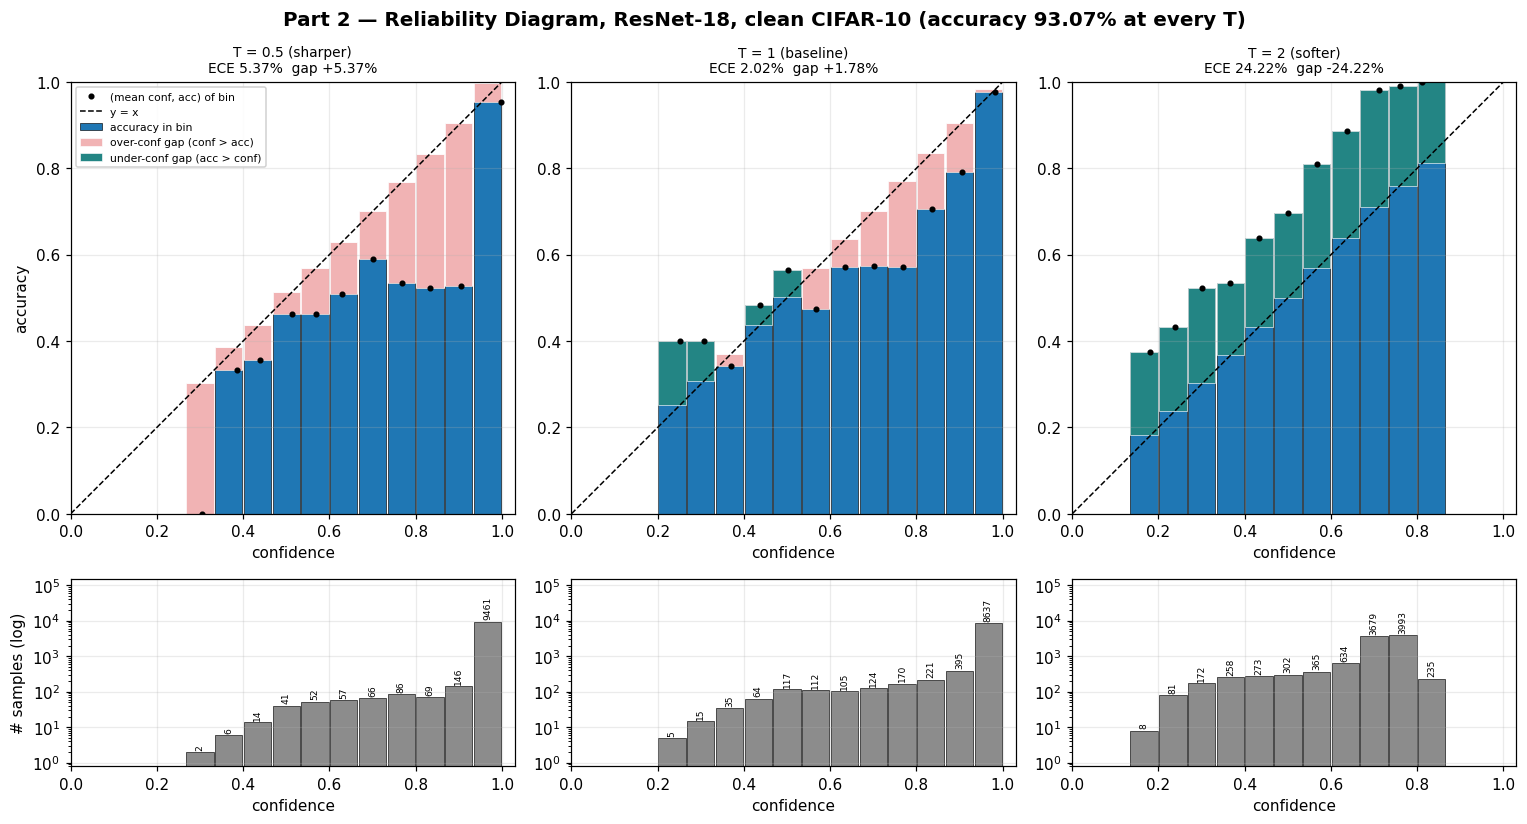

In [8]:
fig, axs = plt.subplots(2, 3, figsize=(14, 7.6), gridspec_kw={"height_ratios": [3, 1.3]}, sharex=True)
for j, T in enumerate(TS):
    r = REC[T]
    cm.plot_reliability(axs[0, j], r["conf"], r["correct"],
                        title=f"{T_NAME[T]}\nECE {100*cm.ece_score(r['conf'], r['correct']):.2f}%  gap {100*cm.signed_gap(r['conf'], r['correct']):+.2f}%")
    cm.plot_bin_counts(axs[1, j], r["conf"])
    if j: axs[0, j].set_ylabel(""); axs[1, j].set_ylabel("")
    axs[0, j].tick_params(labelbottom=True)
axs[0, 0].legend(loc="upper left", fontsize=7)
fig.suptitle(f"Part 2 — Reliability Diagram, ResNet-18, clean CIFAR-10 (accuracy {100*ACC:.2f}% at every T)")
plt.tight_layout(); savefig("reliability"); plt.show()

## Cell 4 — ECE, ACE, signed gap (R6, R7)
*Direction on diagram* = hướng lệch của phần lớn số mẫu (theo bin); cột cuối kiểm tra dấu của signed gap có khớp hướng đó không (R7).

In [9]:
point = []
for T in TS:
    r = REC[T]; g, n = cm.binwise_gap(r["conf"], r["correct"])
    over = n[(n > 0) & (g > 0)].sum() / n.sum(); under = n[(n > 0) & (g < 0)].sum() / n.sum()
    gap = cm.signed_gap(r["conf"], r["correct"]); d = "over" if over > under else "under"
    point.append({"T": T, "mean conf %": 100 * r["conf"].mean(), "signed gap %": 100 * gap,
                  "ECE %": 100 * cm.ece_score(r["conf"], r["correct"]), "ACE %": 100 * cm.ace_score(r["conf"], r["correct"]),
                  "direction on diagram": f"{d} ({max(over, under):.0%} of samples)", "sign matches (R7)": (gap > 0) == (d == "over")})
POINT = pd.DataFrame(point).set_index("T"); display(POINT.round(2))

,mean conf %,signed gap %,ECE %,ACE %,direction on diagram,sign matches (R7)
T,,,,,,
0.5,98.44,5.37,5.37,5.37,over (100% of samples),True
1.0,94.85,1.78,2.02,2.41,over (98% of samples),True
2.0,68.85,-24.22,24.22,24.22,under (100% of samples),True


## Cell 5 — Risk–Coverage và ranking (R8, R9)
Sắp xếp prediction theo confidence, chấp nhận phần tự tin nhất. *Oracle* = xếp mọi prediction đúng lên trước (risk thấp nhất có thể); *random* = confidence vô dụng. Đọc cả hình dạng đường cong, không chỉ một con số.

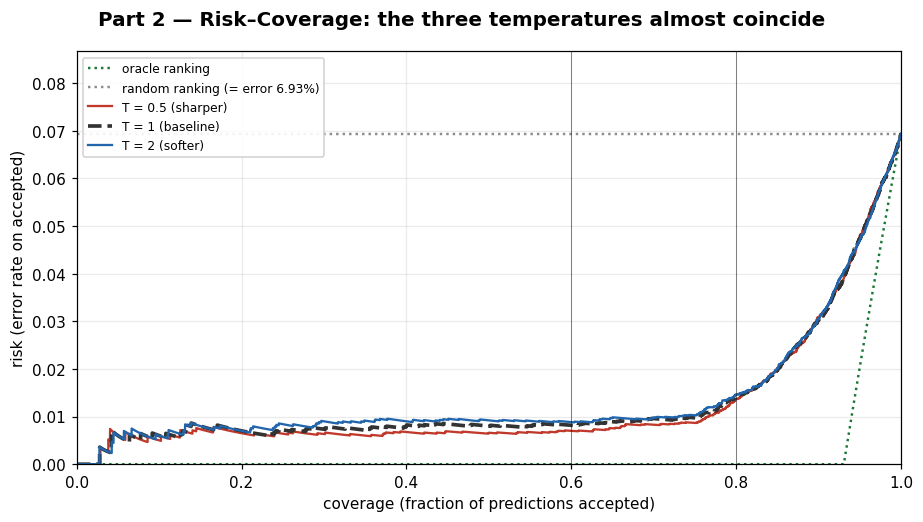

,Risk@80% %,Risk@60% %,E-AURC %,spearman,overlap_top80,overlap_top60
T,,,,,,
0.5,1.3625,0.7000,0.9781,0.9937,0.9945,0.9702
1.0,1.4375,0.8167,1.0523,1.0000,1.0000,1.0000
2.0,1.4625,0.8833,1.1135,0.9982,0.9956,0.9865


In [10]:
err = 1 - ACC
cov_o, risk_o = cm.risk_coverage(cm.oracle_score(corr), corr)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(cov_o, risk_o, ":", color=cm.C["oracle"], lw=1.6, label="oracle ranking")
ax.axhline(err, ls=":", color=cm.C["random"], lw=1.6, label=f"random ranking (= error {100*err:.2f}%)")
for T in TS:
    cm.plot_risk_coverage(ax, REC[T]["score"], REC[T]["correct"], color=T_COLOR[T], lw=2.4 if T == 1 else 1.5, ls="--" if T == 1 else "-", label=T_NAME[T])
for c in COVS: ax.axvline(c, color="k", lw=.6, alpha=.5)
ax.set_ylim(0, err * 1.25); ax.legend(fontsize=8, loc="upper left"); fig.suptitle("Part 2 — Risk–Coverage: the three temperatures almost coincide")
plt.tight_layout(); savefig("risk_coverage"); plt.show()

rows = []
for T in TS:
    r = REC[T]; row = {"T": T, "Risk@80% %": 100 * cm.risk_at(r["score"], corr, .8), "Risk@60% %": 100 * cm.risk_at(r["score"], corr, .6),
                       "E-AURC %": 100 * cm.e_aurc(r["score"], corr)}
    row.update({k: v for k, v in cm.ranking_agreement(REC[1.0]["score"], r["score"]).items() if k != "kendall"})
    rows.append(row)
RANK = pd.DataFrame(rows).set_index("T"); savetab(RANK, "ranking"); display(RANK.round(4))

Ranking được giữ **gần như** nguyên (Spearman ≥ 0.99), không tuyệt đối: max softmax phụ thuộc cả vector logits. Khác biệt nhỏ có hướng nhất quán (T nhỏ → risk thấp hơn một chút) vì T nhỏ xếp hạng theo khoảng cách giữa hai logit lớn nhất, T lớn xếp theo khoảng cách của logit lớn nhất tới trung bình — xem **Phụ lục A**.

## Cell 6 — Đối chứng dương: Risk–Coverage có "mù" không? (R11)
Cố ý **phá ranking**: cộng nhiễu Gaussian σ vào confidence ở T = 1 (20 lần mỗi σ). Công cụ nhạy thì risk phải tăng rõ theo σ, về phía random.

,Risk@80% %,Risk@60% %,E-AURC %,spearman vs T=1
condition,,,,
oracle,0.000,0.000,0.000,NaN
T = 1.0,1.438,0.817,1.052,1.000
noise sigma=0.003,1.409,0.890,1.099,0.918
noise sigma=0.01,1.561,1.162,1.286,0.700
noise sigma=0.03,2.153,1.780,1.744,0.502
noise sigma=0.1,3.299,2.744,2.584,0.329
noise sigma=0.3,5.098,4.423,4.106,0.174
random,6.964,7.008,6.726,0.001


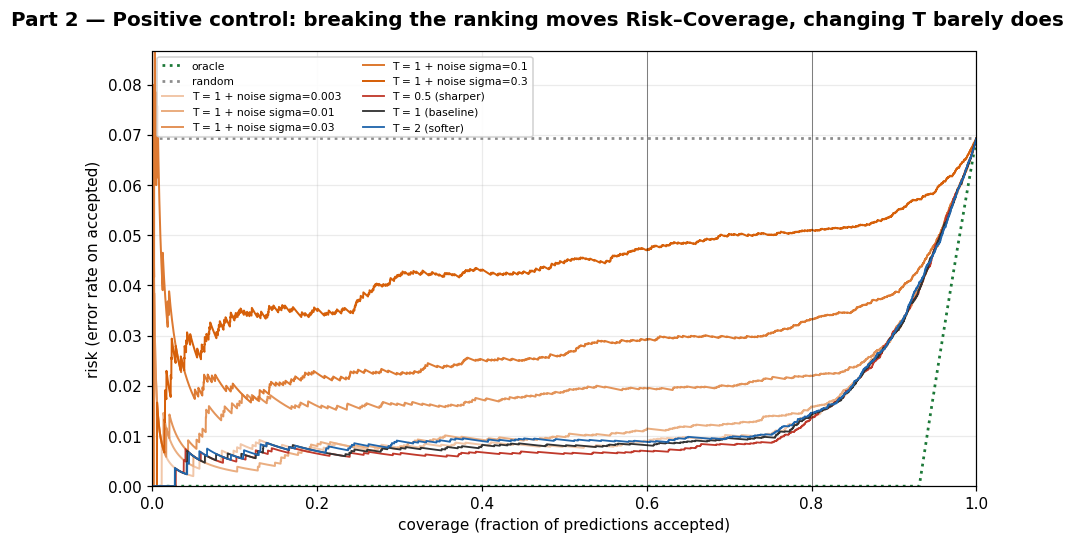

In [11]:
SIGMAS, REPS = [0.003, 0.01, 0.03, 0.1, 0.3], 20
conf1 = REC[1.0]["conf"]; rng = np.random.default_rng(SEED)
pc = []
def add(name, sigma, score):
    pc.append({"condition": name, "sigma": sigma, "Risk@80%": cm.risk_at(score, corr, .8), "Risk@60%": cm.risk_at(score, corr, .6),
               "E-AURC": cm.e_aurc(score, corr), "spearman vs T=1": cm.ranking_agreement(REC[1.0]["score"], score)["spearman"]})
add("oracle", 0, cm.oracle_score(corr))
for T in TS: add(f"T = {T}", 0, REC[T]["score"])
NOISY = {}
for s in SIGMAS:
    for rep in range(REPS):
        sc = conf1 + s * rng.standard_normal(N); add(f"noise sigma={s}", s, sc)
        if rep == 0: NOISY[s] = sc
for rep in range(REPS): add("random", np.inf, rng.permutation(N).astype(float))
PC = pd.DataFrame(pc); savetab(PC, "positive_control_runs", index=False)
PCS = PC.groupby("condition", sort=False).agg(**{k + " %": (k, lambda v: 100 * v.mean()) for k in ["Risk@80%", "Risk@60%", "E-AURC"]},
                                               **{"spearman vs T=1": ("spearman vs T=1", "mean")})
savetab(PCS, "positive_control")
shown = PCS.drop(index=["T = 0.5", "T = 2.0"]).copy(); shown.loc["oracle", "spearman vs T=1"] = np.nan   # T rows: Cell 5; oracle rho: ties, meaningless
display(shown.round(3))

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(cov_o, risk_o, ":", color=cm.C["oracle"], lw=1.8, label="oracle")
ax.axhline(err, ls=":", color=cm.C["random"], lw=1.8, label="random")
NOISE_COL = cm.shades(cm.PAL["orange"], len(SIGMAS))          # one hue, light to dark = small to large noise
for i, s in enumerate(SIGMAS):
    cm.plot_risk_coverage(ax, NOISY[s], corr, color=NOISE_COL[i], lw=1.3, label=f"T = 1 + noise sigma={s}")
for T in TS: cm.plot_risk_coverage(ax, REC[T]["score"], REC[T]["correct"], color=T_COLOR[T], lw=1.2, label=T_NAME[T])
for c in COVS: ax.axvline(c, color="k", lw=.6, alpha=.5)
ax.set_ylim(0, err * 1.25); ax.legend(fontsize=7, loc="upper left", ncol=2)
fig.suptitle("Part 2 — Positive control: breaking the ranking moves Risk–Coverage, changing T barely does")
plt.tight_layout(); savefig("positive_control"); plt.show()

## Cell 7 — Đối chứng ngược: calibration hoàn hảo nhưng ranking vô dụng
Cell 3–6 chứng minh một chiều: **calibration lệch, ranking giữ nguyên**. Cell này chứng minh chiều ngược lại: **calibration tốt, ranking hỏng**. Hai confidence được dựng sẵn (dùng nhãn test, chỉ để làm đối chứng, không phải phương pháp dùng được):
- **Hằng số = accuracy** (93.07% cho mọi ảnh): calibration hoàn hảo nhưng không mang thông tin gì — đúng ví dụ "calibrated nhưng vô ích" của Ovadia et al. (2019). Mọi ảnh bằng điểm nhau nên thứ tự do cách phá thế hòa quyết định; ta đo thêm với 200 lần phá thế hòa ngẫu nhiên.
- **Precision của class được dự đoán**: mọi prediction thuộc class k nhận confidence = tỷ lệ đúng của class k. Cũng calibration hoàn hảo theo cách dựng, nhưng còn một chút thông tin để xếp hạng.

ECE bằng 0 chính xác vì mỗi bin chứa trọn các nhóm mẫu có cùng confidence. ACE không bằng 0 vì bin cùng số mẫu cắt ngang các nhóm đó, nên accuracy mỗi bin dao động ngẫu nhiên quanh giá trị đúng.

,ECE %,ACE %,signed gap %,Risk@80% %,Risk@60% %,E-AURC %
confidence,,,,,,
"model, T = 1",2.024,2.411,1.778,1.438,0.817,1.052
constant = accuracy,0.000,0.808,0.000,6.975,7.000,6.931
precision of predicted class,0.000,0.421,0.000,5.350,4.417,4.124
reference: random ranking,NaN,NaN,NaN,6.964,7.008,6.726


constant confidence, 200 random tie-breaks: Risk@80% = 6.92% (95% range 6.66-7.18%)


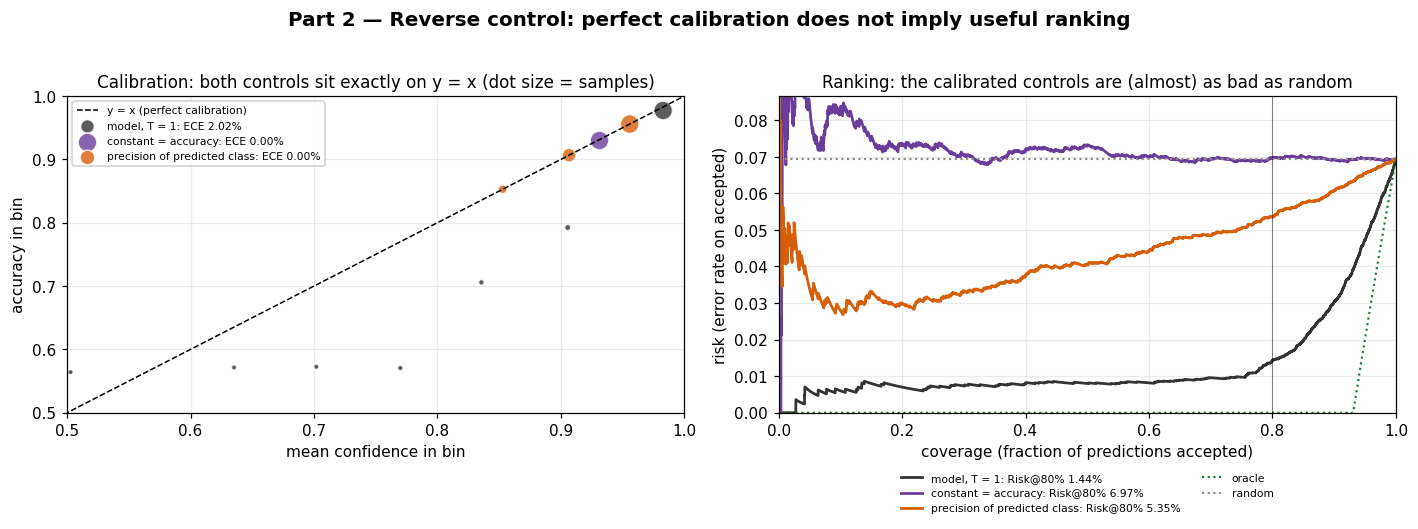

In [12]:
pred1 = REC[1.0]["pred"]
prec = np.array([corr[pred1 == k].mean() for k in range(10)])
CTRL = {"model, T = 1": (REC[1.0]["conf"], REC[1.0]["score"]),
        "constant = accuracy": (np.full(N, ACC), np.full(N, ACC)),
        "precision of predicted class": (prec[pred1], prec[pred1])}
rows = []
for name, (c, s) in CTRL.items():
    rows.append({"confidence": name, "ECE %": 100 * cm.ece_score(c, corr), "ACE %": 100 * cm.ace_score(c, corr),
                 "signed gap %": 100 * cm.signed_gap(c, corr), "Risk@80% %": 100 * cm.risk_at(s, corr, .8),
                 "Risk@60% %": 100 * cm.risk_at(s, corr, .6), "E-AURC %": 100 * cm.e_aurc(s, corr)})
rows.append({"confidence": "reference: random ranking", "Risk@80% %": PCS.loc["random", "Risk@80% %"],
             "Risk@60% %": PCS.loc["random", "Risk@60% %"], "E-AURC %": PCS.loc["random", "E-AURC %"]})
REV = pd.DataFrame(rows).set_index("confidence"); savetab(REV, "reverse_control"); display(REV.round(3))
tie = [100 * (1 - corr[np.random.default_rng(SEED + i).permutation(N)[:int(.8 * N)]].mean()) for i in range(200)]
print(f"constant confidence, 200 random tie-breaks: Risk@80% = {np.mean(tie):.2f}% (95% range {np.percentile(tie, 2.5):.2f}-{np.percentile(tie, 97.5):.2f}%)")

CCOL = {"model, T = 1": T_COLOR[1.0], "constant = accuracy": cm.PAL["purple"], "precision of predicted class": cm.PAL["orange"]}
fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
axs[0].plot([0, 1], [0, 1], "--", color=cm.C["diag"], lw=1, label="y = x (perfect calibration)")
for name, (c, s) in CTRL.items():
    bc, ba, n = cm.reliability_bins(c, corr); ok = n >= 20                    # bins with at least 20 samples
    axs[0].scatter(bc[ok], ba[ok], s=10 + 140 * n[ok] / n.max(), color=CCOL[name], alpha=.8, edgecolor="white",
                   label=f"{name}: ECE {100*cm.ece_score(c, corr):.2f}%")
    cm.plot_risk_coverage(axs[1], s, corr, color=CCOL[name], lw=1.8, label=f"{name}: Risk@80% {100*cm.risk_at(s, corr, .8):.2f}%")
axs[0].set_xlim(.5, 1); axs[0].set_ylim(.5, 1); axs[0].set_xlabel("mean confidence in bin"); axs[0].set_ylabel("accuracy in bin")
axs[0].set_title("Calibration: both controls sit exactly on y = x (dot size = samples)"); axs[0].legend(fontsize=7, loc="upper left")
axs[1].plot(cov_o, risk_o, ":", color=cm.C["oracle"], lw=1.4, label="oracle")
axs[1].axhline(err, ls=":", color=cm.C["random"], lw=1.4, label="random")
axs[1].axvline(.8, color="k", lw=.6, alpha=.5); axs[1].set_ylim(0, err * 1.25)
axs[1].set_title("Ranking: the calibrated controls are (almost) as bad as random")
axs[1].legend(fontsize=7, loc="upper center", bbox_to_anchor=(.5, -.16), ncol=2, frameon=False)   # below the axes: curves fill the plot
fig.suptitle("Part 2 — Reverse control: perfect calibration does not imply useful ranking", y=1.02)
plt.tight_layout(); savefig("reverse_control"); plt.show()

## Cell 8 — Khoảng tin cậy (R10)
Paired bootstrap: mỗi lần resample dùng **cùng bộ ảnh** cho cả 3 T, nên CI của **hiệu so với T = 1** hẹp và đáng tin. Hiệu chỉ được coi là có thật khi CI không chứa 0.

In [13]:
t0 = time.time(); BOOT = cm.paired_bootstrap(REC, B=N_BOOT, seed=SEED); print(f"bootstrap ({N_BOOT}x) in {time.time()-t0:.0f}s")
METRICS = ["acc", "conf", "gap", "ece", "ace", "risk80", "risk60"]
LABEL = {"acc": "Acc", "conf": "mean conf", "gap": "signed gap", "ece": "ECE", "ace": "ACE", "risk80": "Risk@80%", "risk60": "Risk@60%"}
POINTFN = {m: cm.DEFAULT_METRICS[m] for m in METRICS}

rows = []
for T in TS:
    row = {"T": T}
    for m in METRICS:
        lo, hi = cm.ci(BOOT[T][m]); row.update({m: POINTFN[m](REC[T]), m + "_lo": lo, m + "_hi": hi})
    rows.append(row)
SUMMARY = pd.DataFrame(rows).set_index("T"); savetab(SUMMARY, "summary")

drows = []
for m in ["gap", "ece", "ace", "risk80", "risk60"]:
    row = {"metric": LABEL[m], "T = 1 value % [95% CI]": f"{100*SUMMARY.loc[1.0, m]:.2f} [{100*SUMMARY.loc[1.0, m+'_lo']:.2f}, {100*SUMMARY.loc[1.0, m+'_hi']:.2f}]"}
    for T in (0.5, 2.0):
        d = BOOT[T][m] - BOOT[1.0][m]; lo, hi = cm.ci(d); v = POINTFN[m](REC[T]) - POINTFN[m](REC[1.0])
        row[f"T={T} minus T=1 (pp) [95% CI]"] = f"{100*v:+.3f} [{100*lo:+.3f}, {100*hi:+.3f}]" + ("" if (lo > 0 or hi < 0) else "  (n.s.)")
        drows.append({"T vs T=1": T, "metric": LABEL[m], "diff (pp)": 100 * v, "CI lo": 100 * lo, "CI hi": 100 * hi, "CI excludes 0": (lo > 0) or (hi < 0)})
    rows.append(row)
DIFF = pd.DataFrame(drows); savetab(DIFF, "diff_vs_T1", index=False)
display(pd.DataFrame([r for r in rows if "metric" in r]).set_index("metric"))
print("(n.s.) = CI contains 0: no detectable difference")

bootstrap (1000x) in 12s


,T = 1 value % [95% CI],T=0.5 minus T=1 (pp) [95% CI],T=2.0 minus T=1 (pp) [95% CI]
metric,,,
signed gap,"1.78 [1.32, 2.22]","+3.597 [+3.492, +3.707]","-25.995 [-26.086, -25.903]"
ECE,"2.02 [1.65, 2.46]","+3.350 [+3.044, +3.573]","+22.194 [+21.373, +22.929]"
ACE,"2.41 [2.03, 2.94]","+2.961 [+2.579, +3.156]","+21.806 [+20.891, +22.570]"
Risk@80%,"1.44 [1.14, 1.69]","-0.075 [-0.150, +0.013] (n.s.)","+0.025 [-0.025, +0.088] (n.s.)"
Risk@60%,"0.82 [0.60, 1.05]","-0.117 [-0.233, -0.017]","+0.067 [+0.017, +0.150]"


(n.s.) = CI contains 0: no detectable difference


## Cell 9 — Ý nghĩa thực tế: vì sao vẫn cần calibration khi ranking đã tốt
Hai cách dùng confidence: **cố định coverage** (chấp nhận 80% tự tin nhất — chỉ phụ thuộc ranking) và **cố định ngưỡng** (chấp nhận nếu confidence ≥ 0.9 — phụ thuộc calibration).

,errors rejected @ coverage 80%,accepted if conf >= 0.9,risk if conf >= 0.9 %,threshold giving 80% coverage
T,,,,
0.5,84%,95.4%,4.94,0.9998
1.0,83%,88.8%,2.76,0.9685
2.0,83%,0.0%,NaN,0.6601


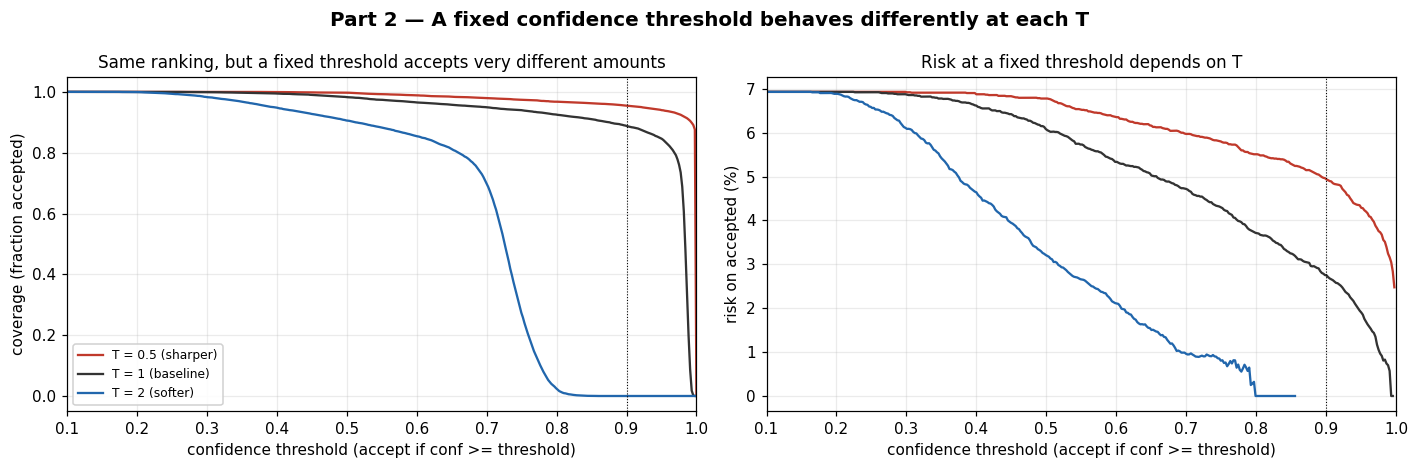

In [14]:
rows = []
for T in TS:
    r = REC[T]; c = r["conf"]; o = np.argsort(-r["score"], kind="stable"); n_err = (1 - corr).sum(); m = c >= 0.9
    rows.append({"T": T, "errors rejected @ coverage 80%": f"{1 - (1 - corr[o[:int(.8 * N)]]).sum() / n_err:.0%}",
                 "accepted if conf >= 0.9": f"{m.mean():.1%}", "risk if conf >= 0.9 %": round(100 * (1 - corr[m].mean()), 2) if m.any() else np.nan,
                 "threshold giving 80% coverage": round(float(np.sort(c)[::-1][int(.8 * N) - 1]), 4)})
PRACT = pd.DataFrame(rows).set_index("T"); savetab(PRACT, "practical_thresholds"); display(PRACT)

th_grid = np.linspace(0.1, 1.0, 400)
fig, axs = plt.subplots(1, 2, figsize=(13, 4.3))
for T in TS:
    c = REC[T]["conf"]
    axs[0].plot(th_grid, [(c >= t).mean() for t in th_grid], color=T_COLOR[T], label=T_NAME[T])
    axs[1].plot(th_grid, [100 * (1 - corr[c >= t].mean()) if (c >= t).any() else np.nan for t in th_grid], color=T_COLOR[T], label=T_NAME[T])
for ax in axs: ax.axvline(0.9, color="k", lw=.7, ls=":"); ax.set_xlabel("confidence threshold (accept if conf >= threshold)"); ax.set_xlim(0.1, 1)
axs[0].set_ylabel("coverage (fraction accepted)"); axs[0].set_title("Same ranking, but a fixed threshold accepts very different amounts")
axs[1].set_ylabel("risk on accepted (%)"); axs[1].set_title("Risk at a fixed threshold depends on T"); axs[0].legend(fontsize=8)
fig.suptitle("Part 2 — A fixed confidence threshold behaves differently at each T")
plt.tight_layout(); savefig("thresholds"); plt.show()

## Cell 10 — Kiểm tra trên 10 kiến trúc của Part 1
Lặp lại đúng thí nghiệm trên 10 checkpoint Part 1 đã chạy (logits lấy từ Part 1, không chạy thêm model). Mỗi nhóm cột là một model, mỗi cột một T (đỏ 0.5, xám đen 1, xanh 2), error bar = 95% CI.

- **Hàng trên (signed gap):** cột đỏ nhô lên trên 0 (overconfident), cột xanh cắm xuống dưới 0 (underconfident) ở **mọi** model → Reliability bắt đúng hướng lệch.
- **Hàng dưới (Risk@80%):** 3 cột của mỗi model gần như cao bằng nhau → đổi T hầu như không đổi ranking.

Bảng đầy đủ và hình hiệu so với T = 1: **Phụ lục F**. Lưu ý: mỗi kiến trúc chỉ có một lần train.

10 models x paired bootstrap (1000x) in 121s


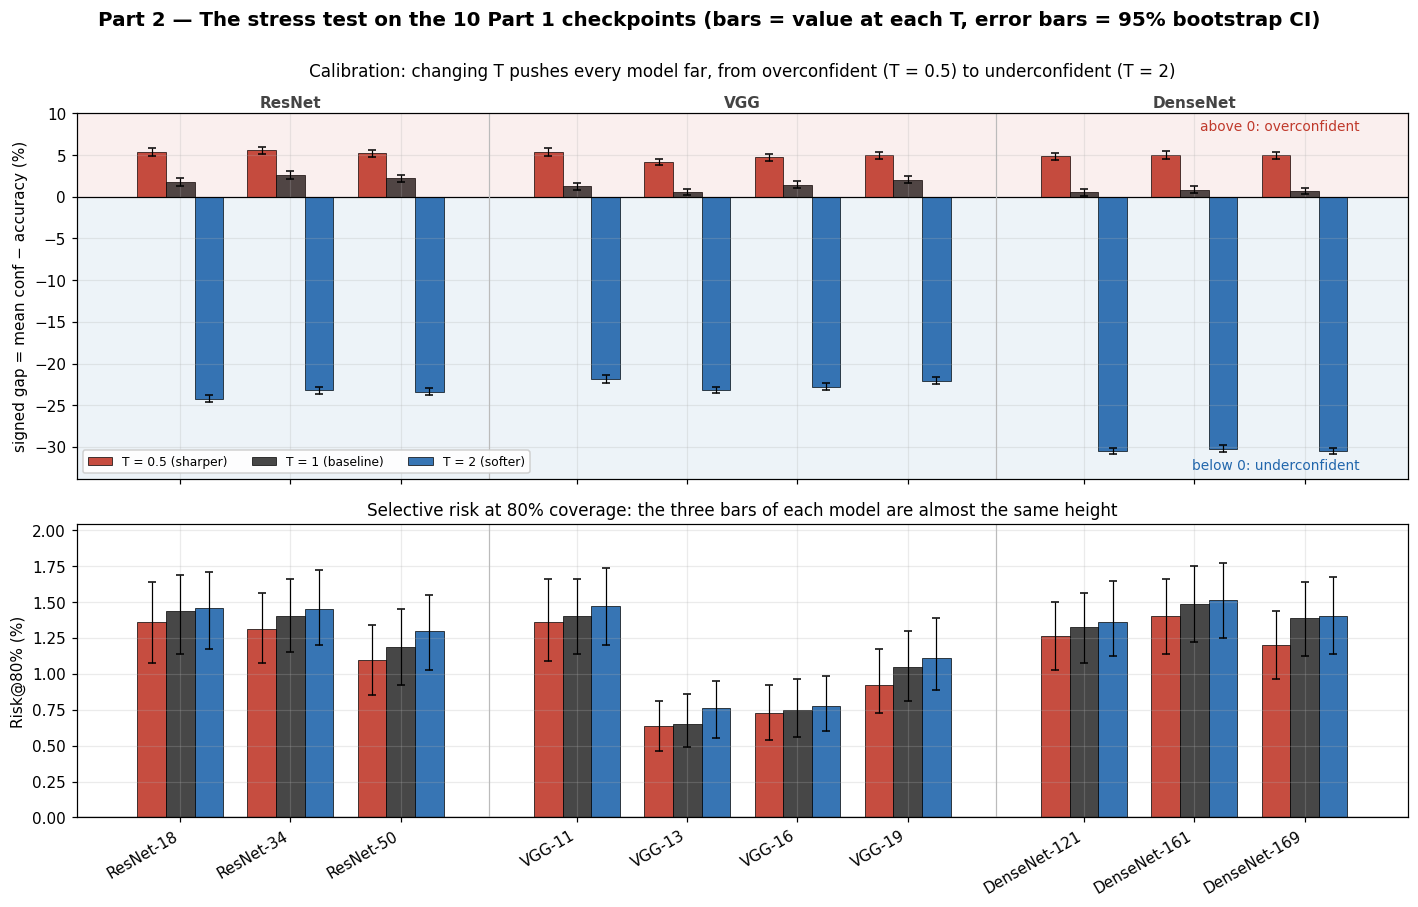

T=0.5: created direction detected 10/10 | dECE significant 10/10 (+2.66 .. +3.83 pp) | dRisk@80% -0.187 .. -0.012 pp | min Spearman 0.967
T=2.0: created direction detected 10/10 | dECE significant 10/10 (+19.93 .. +28.47 pp) | dRisk@80% +0.013 .. +0.113 pp | min Spearman 0.957
smallest |dECE| / largest |dRisk@80%| = 14x


In [15]:
ALL_PATH = "outputs/part1_clean_logits_all.npz"
ROB = ABS = None
if not os.path.exists(ALL_PATH):
    print("Skipped: logits of the 10 Part 1 checkpoints not available (e.g. SOURCE='recompute' on Colab).")
else:
    ALL = np.load(ALL_PATH); assert np.array_equal(ALL["labels"], labels)
    MODELS = [k for k in ALL.files if k != "labels"]; FAM = {m: m.split("_")[0] for m in MODELS}
    rows, abs_rows, t0 = [], [], time.time()
    for mname in MODELS:
        R = {T: cm.predict(ALL[mname], labels, T) for T in TS}
        Bm = cm.paired_bootstrap(R, B=N_BOOT, seed=SEED)
        base = {m: POINTFN[m](R[1.0]) for m in ("gap", "ece", "risk80", "risk60")}
        for T in TS:
            arow = {"model": mname.replace("_", "-"), "family": FAM[mname], "T": T}
            for m in ("acc", "gap", "ece", "ace", "risk80", "risk60"):
                lo, hi = cm.ci(Bm[T][m]); arow.update({m: 100 * POINTFN[m](R[T]), m + "_lo": 100 * lo, m + "_hi": 100 * hi})
            abs_rows.append(arow)
        for T in (0.5, 2.0):
            row = {"model": mname.replace("_", "-"), "family": FAM[mname], "T": T, "acc %": 100 * R[T]["correct"].mean(),
                   "gap@T=1 %": 100 * base["gap"], "gap %": 100 * POINTFN["gap"](R[T]),
                   "spearman vs T=1": cm.ranking_agreement(R[1.0]["score"], R[T]["score"])["spearman"]}
            for m in ("ece", "risk80", "risk60"):
                lo, hi = cm.ci(Bm[T][m] - Bm[1.0][m])
                row.update({f"d{LABEL[m]} (pp)": 100 * (POINTFN[m](R[T]) - base[m]), f"d{LABEL[m]} lo": 100 * lo,
                            f"d{LABEL[m]} hi": 100 * hi, f"d{LABEL[m]} sig": (lo > 0) or (hi < 0)})
            rows.append(row)
    ROB = pd.DataFrame(rows); savetab(ROB, "robustness_10_models", index=False)
    ABS = pd.DataFrame(abs_rows); savetab(ABS, "robustness_10_models_by_T", index=False)
    print(f"{len(MODELS)} models x paired bootstrap ({N_BOOT}x) in {time.time()-t0:.0f}s")

    # Grouped bars in the main.pdf style: one group per model, one bar per T, 95% bootstrap CI as error bars.
    # Top: signed gap (bars above 0 = overconfident, below 0 = underconfident). Bottom: Risk@80% (lower = safer selection).
    names = [m.replace("_", "-") for m in MODELS]
    x = np.arange(len(names)) + np.repeat([0, .6, 1.2], [3, 4, 3])        # small gap between the ResNet / VGG / DenseNet groups
    w = .26
    fig, axs = plt.subplots(2, 1, figsize=(13, 8.2), sharex=True, gridspec_kw={"height_ratios": [1.25, 1]})
    for ax, met, ylab in [(axs[0], "gap", "signed gap = mean conf − accuracy (%)"), (axs[1], "risk80", "Risk@80% (%)")]:
        for k, T in enumerate(TS):
            sub = ABS[ABS["T"] == T].set_index("model").loc[names]
            v = sub[met].values; err = np.vstack([v - sub[met + "_lo"].values, sub[met + "_hi"].values - v])
            ax.bar(x + (k - 1) * w, v, w, yerr=err, color=T_COLOR[T], alpha=.9, edgecolor="k", lw=.5,
                   error_kw={"elinewidth": .8, "capsize": 2.5}, label=T_NAME[T])
        ax.set_ylabel(ylab); ax.axhline(0, color="k", lw=.8)
        for b in (x[2] + x[3]) / 2, (x[6] + x[7]) / 2: ax.axvline(b, color="#bbbbbb", lw=.8)
    lo_y, hi_y = ABS["gap_lo"].min() - 3, ABS["gap_hi"].max() + 4
    axs[0].axhspan(0, hi_y, color=cm.C["over_area"], alpha=.08, lw=0); axs[0].axhspan(lo_y, 0, color=cm.C["under_area"], alpha=.08, lw=0)
    axs[0].set_ylim(lo_y, hi_y)
    axs[0].text(x[-1] + .5, hi_y - .8, "above 0: overconfident", ha="right", va="top", fontsize=9, color=cm.PAL["red"])
    axs[0].text(x[-1] + .5, lo_y + .8, "below 0: underconfident", ha="right", va="bottom", fontsize=9, color=cm.PAL["blue"])
    axs[0].set_title("Calibration: changing T pushes every model far, from overconfident (T = 0.5) to underconfident (T = 2)", pad=24)
    axs[1].set_title("Selective risk at 80% coverage: the three bars of each model are almost the same height")
    axs[1].set_ylim(0, ABS["risk80_hi"].max() * 1.15)
    for xm, fam in ((x[1], "ResNet"), (x[4] + .5, "VGG"), (x[8], "DenseNet")):
        axs[0].text(xm, hi_y + .3, fam, ha="center", va="bottom", fontsize=10, fontweight="bold", color="#444")
    axs[1].set_xticks(x); axs[1].set_xticklabels(names, rotation=30, ha="right")
    axs[0].legend(loc="lower left", ncol=3, fontsize=8)
    fig.suptitle("Part 2 — The stress test on the 10 Part 1 checkpoints (bars = value at each T, error bars = 95% bootstrap CI)", y=1.0)
    plt.tight_layout(); savefig("robustness_10_models"); plt.show()

    for T in (0.5, 2.0):
        sub = ROB[ROB["T"] == T]
        right = ((sub["gap %"] > 0) if T == 0.5 else (sub["gap %"] < 0)).sum()
        print(f"T={T}: created direction detected {right}/{len(sub)} | dECE significant {int(sub['dECE sig'].sum())}/{len(sub)} "
              f"({sub['dECE (pp)'].min():+.2f} .. {sub['dECE (pp)'].max():+.2f} pp) | dRisk@80% {sub['dRisk@80% (pp)'].min():+.3f} .. "
              f"{sub['dRisk@80% (pp)'].max():+.3f} pp | min Spearman {sub['spearman vs T=1'].min():.3f}")
    print(f"smallest |dECE| / largest |dRisk@80%| = {ROB['dECE (pp)'].abs().min() / ROB['dRisk@80% (pp)'].abs().max():.0f}x")

## Cell 11 — Tóm tắt từ số liệu (R12)
Mọi câu dưới đây được sinh từ các bảng ở trên, không viết theo kỳ vọng.

In [16]:
S, D = SUMMARY, DIFF.set_index(["T vs T=1", "metric"])
TABLE = pd.DataFrame({"Acc %": [100 * S.loc[T, "acc"] for T in TS], "ECE %": [100 * S.loc[T, "ece"] for T in TS],
                      "ACE %": [100 * S.loc[T, "ace"] for T in TS], "signed gap %": [100 * S.loc[T, "gap"] for T in TS],
                      "Risk@80% %": [100 * S.loc[T, "risk80"] for T in TS], "Risk@60% %": [100 * S.loc[T, "risk60"] for T in TS]},
                     index=pd.Index(TS, name="T")).round(2)
savetab(TABLE, "table_main"); print(TABLE.to_string(), "\n")
dirs = [("over" if S.loc[T, "gap_lo"] > 0 else "under" if S.loc[T, "gap_hi"] < 0 else "n.s.") for T in TS]
print(f"[1] Reliability: direction at T=0.5/1/2 = {dirs}; matches diagram: {POINT['sign matches (R7)'].all()}")
print(f"[2] Risk@80% change vs T=1: {D.loc[(0.5, 'Risk@80%'), 'diff (pp)']:+.3f} / {D.loc[(2.0, 'Risk@80%'), 'diff (pp)']:+.3f} pp "
      f"(significant: {D.loc[(0.5, 'Risk@80%'), 'CI excludes 0']} / {D.loc[(2.0, 'Risk@80%'), 'CI excludes 0']}); "
      f"min Spearman {RANK['spearman'].min():.4f}")
print(f"[3] Positive control Risk@80%: T=1 {PCS.loc['T = 1.0', 'Risk@80% %']:.2f}% -> sigma=0.03 {PCS.loc['noise sigma=0.03', 'Risk@80% %']:.2f}% "
      f"-> random {PCS.loc['random', 'Risk@80% %']:.2f}%; monotone in sigma: {all(np.diff([PCS.loc[f'noise sigma={s}', 'Risk@80% %'] for s in SIGMAS]) > 0)}")
print(f"[4] Reverse control: constant conf = accuracy -> ECE {REV.loc['constant = accuracy', 'ECE %']:.2f}%, Risk@80% {REV.loc['constant = accuracy', 'Risk@80% %']:.2f}% "
      f"(random {REV.loc['reference: random ranking', 'Risk@80% %']:.2f}%, model {REV.loc['model, T = 1', 'Risk@80% %']:.2f}%)")
print(f"[5] conf >= 0.9 accepts {' / '.join(PRACT['accepted if conf >= 0.9'])} at T = 0.5 / 1 / 2")

     Acc %  ECE %  ACE %  signed gap %  Risk@80% %  Risk@60% %
T                                                             
0.5  93.07   5.37   5.37          5.37        1.36        0.70
1.0  93.07   2.02   2.41          1.78        1.44        0.82
2.0  93.07  24.22  24.22        -24.22        1.46        0.88 

[1] Reliability: direction at T=0.5/1/2 = ['over', 'over', 'under']; matches diagram: True
[2] Risk@80% change vs T=1: -0.075 / +0.025 pp (significant: False / False); min Spearman 0.9937
[3] Positive control Risk@80%: T=1 1.44% -> sigma=0.03 2.15% -> random 6.96%; monotone in sigma: True
[4] Reverse control: constant conf = accuracy -> ECE 0.00%, Risk@80% 6.97% (random 6.96%, model 1.44%)
[5] conf >= 0.9 accepts 95.4% / 88.8% / 0.0% at T = 0.5 / 1 / 2


## Cell 12 — Kết luận Part 2 (R12, R13)

**1. Reliability Diagram phát hiện đúng lỗi calibration đã tạo.** Accuracy giữ nguyên 93.07%. Signed gap: **+1.78%** ở T = 1 (overconfident nhẹ), **+5.37%** ở T = 0.5 (overconfident), **−24.22%** ở T = 2 (underconfident); dấu khớp hướng lệch trên diagram ở cả 3 T. ECE tăng +3.35 và +22.19 điểm %, CI đều loại trừ 0.

**2. Risk–Coverage gần như không đổi nhưng không "mù".** Risk@80% = 1.36 / 1.44 / 1.46%, hiệu so với T = 1 không phát hiện được; Spearman ≥ 0.99. Hiệu ứng nhỏ có hướng nhất quán (Risk@60% thấp hơn ~0.1 điểm % ở T = 0.5) do T nhỏ xếp hạng theo khoảng cách hai logit lớn nhất (Phụ lục A). Khi cố ý phá ranking, Risk@80% tăng đơn điệu tới 6.96%.

**3. Đối chứng ngược: calibration hoàn hảo nhưng ranking vô dụng.** Gán mọi ảnh confidence = accuracy (93.07%) cho ECE = 0.00% nhưng Risk@80% = 6.97%, ngang xếp ngẫu nhiên (6.96%) và gần gấp 5 lần model (1.44%). Confidence = precision của class dự đoán cũng có ECE = 0.00% nhưng Risk@80% = 5.35%. Đúng như Ovadia et al. (2019): calibrated không có nghĩa là hữu ích.

**4. Vậy calibration và ranking độc lập theo cả hai chiều, và cần cả hai.** Calibration lệch nặng mà ranking giữ nguyên (Cell 3–6), và calibration hoàn hảo mà ranking vô dụng (Cell 7). Cùng ranking, nhưng quy tắc "chấp nhận nếu confidence ≥ 0.9" chấp nhận 95.4% / 88.8% / 0% prediction ở T = 0.5 / 1 / 2. Kết quả đúng trên cả **10/10** kiến trúc của Part 1. Part 3 phải đọc cả hai công cụ.

**Vai trò của T.** T = 0.5 và T = 2 chỉ là nhiễu loạn có kiểm soát để kiểm định công cụ đo, **không phải calibration**, khác với T tối ưu của Part 4.

**Giới hạn.**
- Mỗi kiến trúc một lần train, cùng một quy trình; CI chỉ phản ánh nhiễu chọn mẫu test.
- Chỉ dữ liệu sạch, một bộ dữ liệu; không nói gì về hành vi dưới shift (Part 3).
- Confidence dồn mạnh vào bin cuối (86% số mẫu ở T = 1), các bin giữa ít mẫu và nhiễu.

---
# Phụ lục — chi tiết bổ sung
Không cần đọc để hiểu kết luận. Dùng khi cần giải thích sâu hơn hoặc khi bị hỏi.

## Phụ lục A — Vì sao T làm ranking đổi nhẹ, và theo hướng nào
$\log \hat p_{\max}(T) = -\log\big(1 + \sum_{j \ne 1} e^{-(z_1 - z_j)/T}\big)$. Khi $T \to 0$, tổng bị chi phối bởi lớp thứ hai → thứ tự tiến về **margin** $z_1 - z_2$. Khi $T \to \infty$, $\hat p_{\max} \approx \frac{1}{K}(1 + (z_1 - \bar z)/T)$ → thứ tự tiến về $z_1 - \bar z$. T **nội suy** giữa hai cách xếp hạng; cách nào tốt hơn là tính chất của checkpoint.

In [17]:
s_sorted = np.sort(logits.astype(np.float64), 1)
margin, maxmean = s_sorted[:, -1] - s_sorted[:, -2], s_sorted[:, -1] - logits.mean(1)
rows = []
for name, sc in [("margin z1 - z2", margin)] + [(f"confidence, T = {T}", cm.log_confidence(logits, T)) for T in (0.1, 0.25, 0.5, 1, 2, 4, 10)] + [("z1 - mean(z)", maxmean)]:
    rows.append({"ranking score": name, "Risk@80% %": 100 * cm.risk_at(sc, corr, .8), "Risk@60% %": 100 * cm.risk_at(sc, corr, .6),
                 "E-AURC %": 100 * cm.e_aurc(sc, corr), "Spearman vs margin": spearmanr(sc, margin).statistic,
                 "Spearman vs z1-mean": spearmanr(sc, maxmean).statistic})
INTERP = pd.DataFrame(rows).set_index("ranking score"); savetab(INTERP, "T_interpolates_ranking"); display(INTERP.round(4))

,Risk@80% %,Risk@60% %,E-AURC %,Spearman vs margin,Spearman vs z1-mean
ranking score,,,,,
margin z1 - z2,1.3000,0.6500,0.9472,1.0000,0.8991
"confidence, T = 0.1",1.3000,0.6500,0.9419,0.9989,0.9095
"confidence, T = 0.25",1.3000,0.6167,0.9410,0.9888,0.9410
"confidence, T = 0.5",1.3625,0.7000,0.9781,0.9618,0.9764
"confidence, T = 1",1.4375,0.8167,1.0523,0.9327,0.9938
"confidence, T = 2",1.4625,0.8833,1.1135,0.9154,0.9986
"confidence, T = 4",1.4625,0.9333,1.1484,0.9070,0.9997
"confidence, T = 10",1.4500,0.9500,1.1685,0.9022,1.0000
z1 - mean(z),1.4875,1.0000,1.1814,0.8991,1.0000


## Phụ lục B — Thứ hạng từng ảnh và số prediction đổi chỗ

,kendall,swapped into top80 (#),errors among them (top80),swapped into top60 (#),errors among them (top60)
T vs T=1,,,,,
0.5,0.9470,44,2,179,1
2.0,0.9719,35,3,81,4


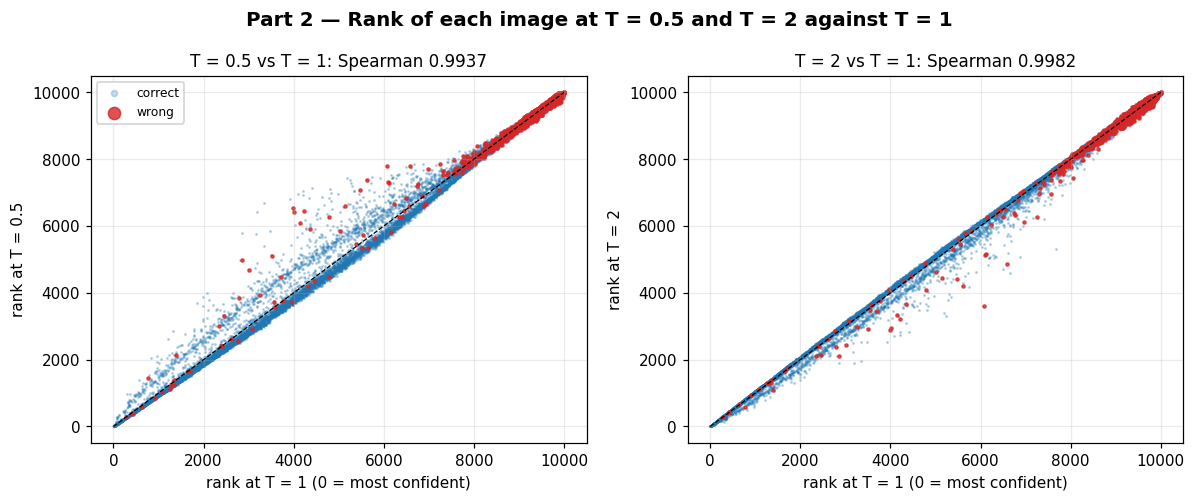

In [18]:
swap = []
for T in (0.5, 2.0):
    row = {"T vs T=1": T, "kendall": cm.ranking_agreement(REC[1.0]["score"], REC[T]["score"])["kendall"]}
    for f in COVS:
        k = int(round(f * N))
        a = set(np.argsort(-REC[1.0]["score"], kind="stable")[:k]); b = set(np.argsort(-REC[T]["score"], kind="stable")[:k])
        row[f"swapped into top{int(100*f)} (#)"] = len(b - a); row[f"errors among them (top{int(100*f)})"] = int(sum(1 - corr[i] for i in b - a))
    swap.append(row)
display(pd.DataFrame(swap).set_index("T vs T=1").round(4))

rank = {T: np.argsort(np.argsort(-REC[T]["score"], kind="stable")) for T in TS}
fig, axs = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, T in zip(axs, (0.5, 2.0)):
    ax.scatter(rank[1.0][corr == 1], rank[T][corr == 1], s=1, alpha=.25, color=cm.C["correct"], label="correct")
    ax.scatter(rank[1.0][corr == 0], rank[T][corr == 0], s=4, alpha=.8, color=cm.C["wrong"], label="wrong")
    ax.plot([0, N], [0, N], "k--", lw=.8)
    ax.set_xlabel("rank at T = 1 (0 = most confident)"); ax.set_ylabel(f"rank at T = {T:g}")
    ax.set_title(f"T = {T:g} vs T = 1: Spearman {RANK.loc[T, 'spearman']:.4f}")
axs[0].legend(markerscale=4, fontsize=8)
fig.suptitle("Part 2 — Rank of each image at T = 0.5 and T = 2 against T = 1")
plt.tight_layout(); savefig("ranking"); plt.show()

## Phụ lục C — Phóng to khác biệt giữa các đường Risk–Coverage

T=0.5: max |risk_T - risk_1| for coverage >= 5% = 0.216 pp
T=2.0: max |risk_T - risk_1| for coverage >= 5% = 0.201 pp


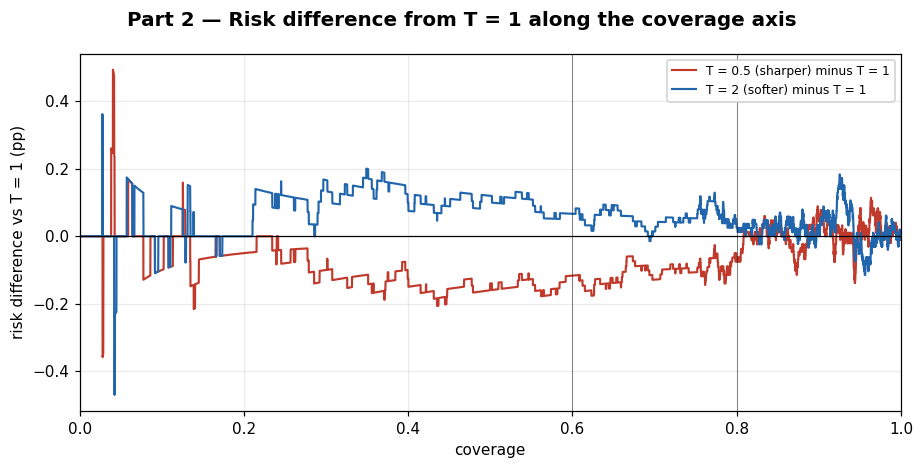

In [19]:
cov1, risk1 = cm.risk_coverage(REC[1.0]["score"], corr)
fig, ax = plt.subplots(figsize=(8.5, 4.3))
for T in (0.5, 2.0):
    cov, risk = cm.risk_coverage(REC[T]["score"], corr)
    ax.plot(cov, 100 * (risk - risk1), color=T_COLOR[T], lw=1.4, label=f"{T_NAME[T]} minus T = 1")
    print(f"T={T}: max |risk_T - risk_1| for coverage >= 5% = {100*np.abs(risk - risk1)[cov1 >= .05].max():.3f} pp")
ax.axhline(0, color="k", lw=.8); ax.set_xlim(0, 1)
for c in COVS: ax.axvline(c, color="k", lw=.6, alpha=.5)
ax.set_xlabel("coverage"); ax.set_ylabel("risk difference vs T = 1 (pp)"); ax.legend(fontsize=8)
fig.suptitle("Part 2 — Risk difference from T = 1 along the coverage axis")
plt.tight_layout(); savefig("risk_coverage_zoom"); plt.show()

## Phụ lục D — Hình khoảng tin cậy của từng metric

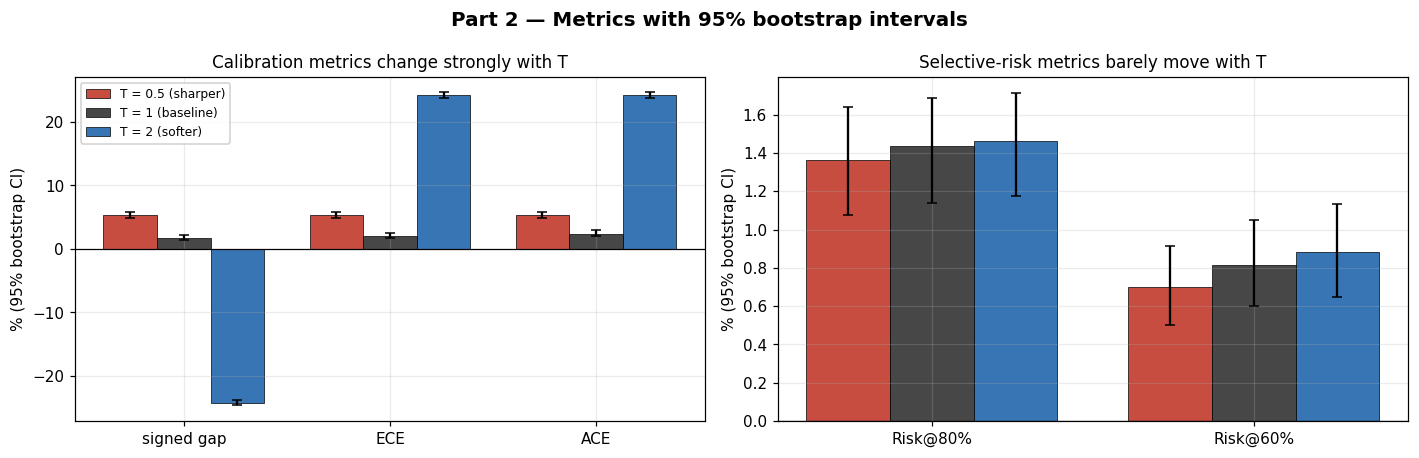

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, group, title in [(axs[0], ["gap", "ece", "ace"], "Calibration metrics change strongly with T"),
                         (axs[1], ["risk80", "risk60"], "Selective-risk metrics barely move with T")]:
    x = np.arange(len(group)); w = .26
    for i, T in enumerate(TS):
        y = np.array([100 * SUMMARY.loc[T, m] for m in group])
        e = np.vstack([y - [100 * SUMMARY.loc[T, m + "_lo"] for m in group], [100 * SUMMARY.loc[T, m + "_hi"] for m in group] - y])
        ax.bar(x + (i - 1) * w, y, w, yerr=e, capsize=3, color=T_COLOR[T], alpha=.9, label=T_NAME[T], edgecolor="k", lw=.5)
    ax.set_xticks(x); ax.set_xticklabels([LABEL[m] for m in group]); ax.axhline(0, color="k", lw=.8)
    ax.set_ylabel("% (95% bootstrap CI)"); ax.set_title(title)
axs[0].legend(fontsize=8)
fig.suptitle("Part 2 — Metrics with 95% bootstrap intervals")
plt.tight_layout(); savefig("metrics_ci"); plt.show()

## Phụ lục E — Chi tiết theo bin và phân bố confidence
Bin nào đóng góp vào ECE, và confidence dồn vào đâu.

In [21]:
BIN, dist = [], []
for T in TS:
    r = REC[T]; c = r["conf"]; g, n = cm.binwise_gap(c, r["correct"]); bc, ba, _ = cm.reliability_bins(c, r["correct"])
    contrib = np.nan_to_num(n * np.abs(bc - ba)) / N
    dist.append({"T": T, "median conf %": 100 * np.median(c), "share in last bin (> 14/15)": f"{(c > 14/15).mean():.1%}",
                 "share conf > 0.99": f"{(c > .99).mean():.1%}", "ECE share: last bin": f"{contrib[-1] / contrib.sum():.0%}",
                 "ECE share: bins (9/15, 14/15]": f"{contrib[9:14].sum() / contrib.sum():.0%}"})
    for m in range(N_BINS):
        if n[m] > 0:
            BIN.append({"T": T, "bin": f"({m}/15, {m+1}/15]", "n": int(n[m]), "mean conf": bc[m], "acc": ba[m], "gap (conf-acc)": g[m]})
BIN = pd.DataFrame(BIN); savetab(BIN, "binwise_gap", index=False)
display(pd.DataFrame(dist).set_index("T"))
display(BIN.pivot_table(index="bin", columns="T", values=["n", "gap (conf-acc)"], sort=False).round(3))

,median conf %,share in last bin (> 14/15),share conf > 0.99,ECE share: last bin,"ECE share: bins (9/15, 14/15]"
T,,,,,
0.5,99.996619,94.6%,90.7%,78%,21%
1.0,98.390334,86.4%,13.2%,24%,64%
2.0,72.575357,0.0%,0.0%,0%,88%


n                 gap (conf-acc)              
T                  0.5     1.0     2.0            0.5    1.0    2.0
bin                                                                
(4/15, 5/15]       2.0    15.0   172.0          0.303 -0.091 -0.221
(5/15, 6/15]       6.0    35.0   258.0          0.053  0.028 -0.168
(6/15, 7/15]      14.0    64.0   273.0          0.081 -0.047 -0.204
(7/15, 8/15]      41.0   117.0   302.0          0.050 -0.061 -0.195
(8/15, 9/15]      52.0   112.0   365.0          0.107  0.095 -0.242
(9/15, 10/15]     57.0   105.0   634.0          0.122  0.064 -0.248
(10/15, 11/15]    66.0   124.0  3679.0          0.109  0.129 -0.271
(11/15, 12/15]    86.0   170.0  3993.0          0.232  0.199 -0.231
(12/15, 13/15]    69.0   221.0   235.0          0.312  0.130 -0.188
(13/15, 14/15]   146.0   395.0     NaN          0.377  0.113    NaN
(14/15, 15/15]  9461.0  8637.0     NaN          0.044  0.006    NaN
(3/15, 4/15]       NaN     5.0    81.0            NaN -0.147 -0.194
(2/15, 3/15]       NaN     NaN     8.0            NaN    NaN -0.194

## Phụ lục F — Kiểm tra 10 kiến trúc: bảng đầy đủ và hiệu so với T = 1

,model,T,acc %,gap@T=1 %,gap %,dECE (pp),dRisk@80% (pp),dRisk@80% sig,dRisk@60% (pp),dRisk@60% sig,spearman vs T=1
0,ResNet-18,0.5,93.07,1.778,5.374,3.350,-0.075,False,-0.117,True,0.994
1,ResNet-18,2.0,93.07,1.778,-24.218,22.194,0.025,False,0.067,True,0.998
2,ResNet-34,0.5,93.33,2.595,5.564,2.964,-0.087,True,-0.050,False,0.989
3,ResNet-34,2.0,93.33,2.595,-23.192,20.572,0.050,False,0.067,True,0.998
4,ResNet-50,0.5,93.65,2.218,5.206,2.973,-0.087,False,-0.117,True,0.983
5,ResNet-50,2.0,93.65,2.218,-23.364,21.157,0.113,True,0.000,False,0.996
6,VGG-11,0.5,92.39,1.243,5.326,3.835,-0.038,False,-0.067,False,0.995
7,VGG-11,2.0,92.39,1.243,-21.897,20.395,0.075,False,0.017,False,0.994
8,VGG-13,0.5,94.21,0.587,4.181,3.119,-0.012,False,-0.067,False,0.992
9,VGG-13,2.0,94.21,0.587,-23.144,22.035,0.113,True,0.017,False,0.987


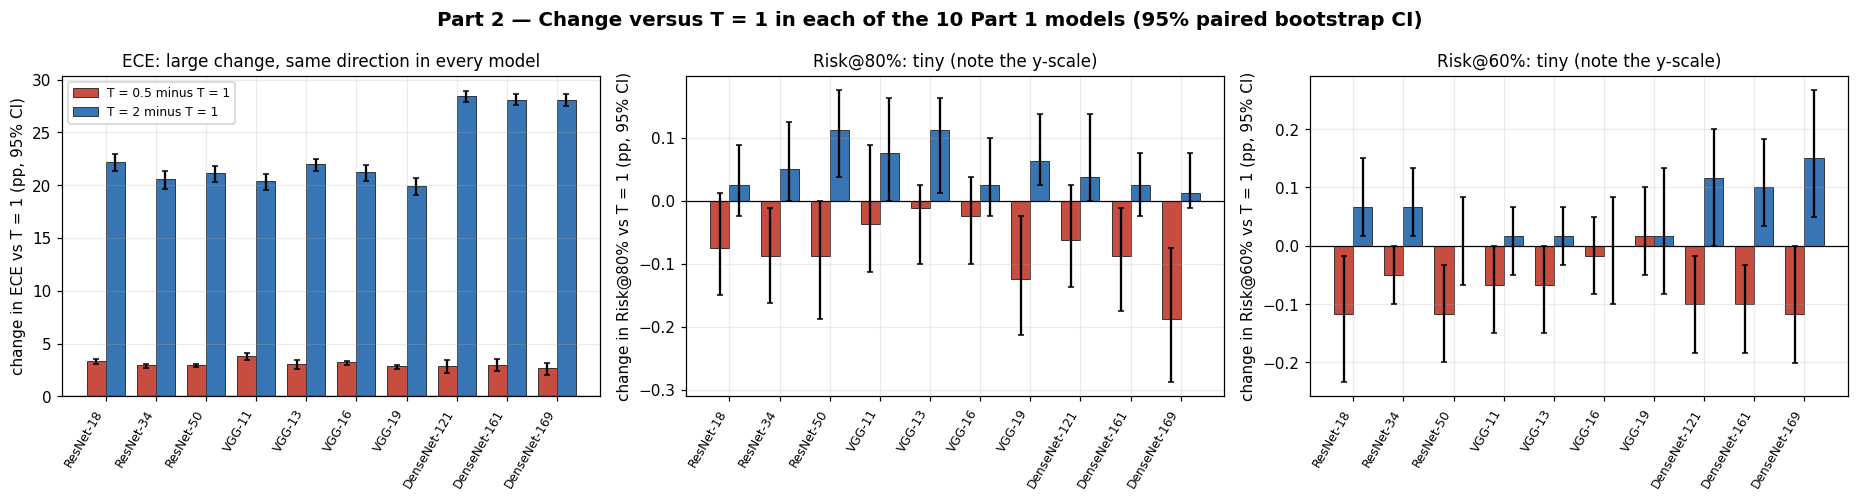

In [22]:
if ROB is None:
    print("Skipped (no 10-model logits).")
else:
    display(ROB[["model", "T", "acc %", "gap@T=1 %", "gap %", "dECE (pp)", "dRisk@80% (pp)", "dRisk@80% sig",
                 "dRisk@60% (pp)", "dRisk@60% sig", "spearman vs T=1"]].round(3))
    fig, axs = plt.subplots(1, 3, figsize=(17, 4.6))
    labels_m = [m.replace("_", "-") for m in MODELS]; x = np.arange(len(MODELS)); w = .38
    for ax, met in zip(axs, ["ECE", "Risk@80%", "Risk@60%"]):
        for i, T in enumerate((0.5, 2.0)):
            sub = ROB[ROB["T"] == T].set_index("model").loc[labels_m]
            y = sub[f"d{met} (pp)"].values; e = np.vstack([y - sub[f"d{met} lo"].values, sub[f"d{met} hi"].values - y])
            ax.bar(x + (i - .5) * w, y, w, yerr=e, capsize=2, color=T_COLOR[T], alpha=.9, edgecolor="k", lw=.5, label=f"T = {T:g} minus T = 1")
        ax.axhline(0, color="k", lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels_m, rotation=60, ha="right", fontsize=8)
        ax.set_ylabel(f"change in {met} vs T = 1 (pp, 95% CI)")
    axs[0].set_title("ECE: large change, same direction in every model"); axs[1].set_title("Risk@80%: tiny (note the y-scale)")
    axs[2].set_title("Risk@60%: tiny (note the y-scale)"); axs[0].legend(fontsize=8)
    fig.suptitle("Part 2 — Change versus T = 1 in each of the 10 Part 1 models (95% paired bootstrap CI)")
    plt.tight_layout(); plt.savefig(f"{OUT_FIG}/{cm.fig_name(2, 'robustness_10_models', 'diff')}", dpi=150, bbox_inches="tight"); plt.show()

## Lưu và tải kết quả

In [23]:
import shutil
shutil.make_archive(os.path.join(BASE, "part2_results"), "zip", WORK, ".")
print("archive:", os.path.join(BASE, "part2_results.zip"))
print(sorted(os.listdir("figures")), sorted(os.listdir("tables")))
try:
    from google.colab import files; files.download(os.path.join(BASE, "part2_results.zip"))
except Exception:
    print("Not in Colab: results are in", WORK)

archive: /content/part2_results.zip
['fig_p2_metrics_ci.png', 'fig_p2_positive_control.png', 'fig_p2_ranking.png', 'fig_p2_reliability.png', 'fig_p2_reverse_control.png', 'fig_p2_risk_coverage.png', 'fig_p2_risk_coverage_zoom.png', 'fig_p2_robustness_10_models.png', 'fig_p2_robustness_10_models_diff.png', 'fig_p2_thresholds.png'] ['p2_T_interpolates_ranking.csv', 'p2_binwise_gap.csv', 'p2_diff_vs_T1.csv', 'p2_positive_control.csv', 'p2_positive_control_runs.csv', 'p2_practical_thresholds.csv', 'p2_ranking.csv', 'p2_reverse_control.csv', 'p2_robustness_10_models.csv', 'p2_robustness_10_models_by_T.csv', 'p2_summary.csv', 'p2_table_main.csv']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>